<a href="https://colab.research.google.com/github/sahabi75/Football-Players-Performance-Prediction/blob/main/Midfielder%20Performance%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
import shap

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")
import warnings
warnings.filterwarnings("ignore")



In [ ]:
db = pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/biometric_dataset.csv')
db.head()

,FullName,Age,Height(m),Position,Foot,CurrentClub,Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg
0,Julio César Soler Barreto,20.0,1.75,Defender,Left,AFC Bournemouth,11150.0,975.0,375.0,21.5,60.0,55.0,500.0,NaN,60.0,200.0,225.0,85.0,8.75,5.0,2.50,200.0,52.5,88.0,52.5,4.0,1.00,500.0,11150.0,4500.0,90.0,8.0,5.25,6.62
1,Ilya Zabarnyi,22.0,1.89,Defender,Right,AFC Bournemouth,11500.0,1500.0,500.0,20.0,100.0,90.0,750.0,70.0,52.5,200.0,300.0,82.5,8.25,5.0,2.50,200.0,60.0,90.0,52.5,4.5,NaN,750.0,11500.0,4700.0,94.5,7.0,5.00,6.00
2,Justin Dean Kluivert,26.0,1.72,Midfielder,Both (ambidextrous),AFC Bournemouth,10500.0,1350.0,700.0,21.5,47.5,42.5,500.0,70.0,60.0,190.0,300.0,85.0,7.75,5.0,2.45,200.0,50.0,95.0,80.0,5.0,2.50,550.0,10500.0,4250.0,93.5,NaN,NaN,6.50
3,Kepa Arrizabalaga Revuelta,30.0,1.88,Goalkeeper,Right,AFC Bournemouth,5350.0,1000.0,300.0,10.0,20.0,15.0,400.0,70.0,50.0,200.0,300.0,85.0,8.00,5.0,NaN,250.0,55.0,90.0,67.5,6.0,5.50,400.0,5250.0,3250.0,93.5,NaN,5.00,5.00
4,William Jonathan Dennis,24.0,1.88,Goalkeeper,Right,AFC Bournemouth,4850.0,375.0,115.0,10.0,32.5,27.5,400.0,75.0,50.0,235.0,225.0,85.0,8.00,5.0,1.70,200.0,60.0,90.0,32.5,4.0,1.75,400.0,4850.0,4000.0,92.0,7.0,5.00,6.00


In [ ]:
db = db.rename(columns={"FullName": "PlayerName"})

In [ ]:
db.head()

,PlayerName,Age,Height(m),Position,Foot,CurrentClub,Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg
0,Julio César Soler Barreto,20.0,1.75,Defender,Left,AFC Bournemouth,11150.0,975.0,375.0,21.5,60.0,55.0,500.0,NaN,60.0,200.0,225.0,85.0,8.75,5.0,2.50,200.0,52.5,88.0,52.5,4.0,1.00,500.0,11150.0,4500.0,90.0,8.0,5.25,6.62
1,Ilya Zabarnyi,22.0,1.89,Defender,Right,AFC Bournemouth,11500.0,1500.0,500.0,20.0,100.0,90.0,750.0,70.0,52.5,200.0,300.0,82.5,8.25,5.0,2.50,200.0,60.0,90.0,52.5,4.5,NaN,750.0,11500.0,4700.0,94.5,7.0,5.00,6.00
2,Justin Dean Kluivert,26.0,1.72,Midfielder,Both (ambidextrous),AFC Bournemouth,10500.0,1350.0,700.0,21.5,47.5,42.5,500.0,70.0,60.0,190.0,300.0,85.0,7.75,5.0,2.45,200.0,50.0,95.0,80.0,5.0,2.50,550.0,10500.0,4250.0,93.5,NaN,NaN,6.50
3,Kepa Arrizabalaga Revuelta,30.0,1.88,Goalkeeper,Right,AFC Bournemouth,5350.0,1000.0,300.0,10.0,20.0,15.0,400.0,70.0,50.0,200.0,300.0,85.0,8.00,5.0,NaN,250.0,55.0,90.0,67.5,6.0,5.50,400.0,5250.0,3250.0,93.5,NaN,5.00,5.00
4,William Jonathan Dennis,24.0,1.88,Goalkeeper,Right,AFC Bournemouth,4850.0,375.0,115.0,10.0,32.5,27.5,400.0,75.0,50.0,235.0,225.0,85.0,8.00,5.0,1.70,200.0,60.0,90.0,32.5,4.0,1.75,400.0,4850.0,4000.0,92.0,7.0,5.00,6.00


In [ ]:
di= pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/injury_dataset.csv')
di.head()

,PlayerName,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,EarlySeasonInjuries_2024_25,MidSeasonInjuries_2024_25,LateSeasonInjuries_2024_25,ContactInjuries_2024_25,NonContactInjuries_2024_25,BothInjuries_2024_25,UnknownInjuries_2024_25,NumberOfInjuries_2024_25,TotalDaysOut_2024_25,EarlySeasonDaysOut_2024_25,MidSeasonDaysOut_2024_25,LateSeasonDaysOut_2024_25,EarlySeasonGamesMissed_2024_25,MidSeasonGamesMissed_2024_25,LateSeasonGamesMissed_2024_25,TotalGamesMissed_2024_25,SeasonsPlayed_Total
0,Aaron Buchanan Hickey,3.0,5.0,1.0,1.0,1.0,3.0,4.0,9.0,726.0,573.0,87.0,66.0,87.0,16.0,12.0,115.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,89.0,0.0,89.0,0.0,0.0,13.0,0.0,13.0,7
1,Aaron Christopher Ramsdale,0.0,1.0,1.0,1.0,0.0,0.0,1.0,2.0,13.0,0.0,7.0,6.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,47.0,40.0,7.0,0.0,6.0,1.0,0.0,7.0,2
2,Aaron Wan-Bissaka,6.0,3.0,1.0,0.0,2.0,3.0,5.0,10.0,252.0,142.0,104.0,6.0,31.0,27.0,1.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
3,Aaron William Cresswell,4.0,7.0,2.0,3.0,7.0,4.0,1.0,15.0,241.0,44.0,45.0,58.0,6.0,12.0,8.0,43.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,11.0,0.0,0.0,11.0,0.0,0.0,2.0,2.0,5
4,Aarón Anselmino,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,109.0,0.0,0.0,51.0,0.0,0.0,11.0,20.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,2.0,120.0,38.0,82.0,0.0,7.0,17.0,0.0,24.0,3


In [ ]:
dp = pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/EPLmid.csv', encoding='latin1')
dp.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,ASR
0,Danilo dos Santos de Oliveira,DDSDO,2025,Botafogo,11,667.0,1,1,9.0,1.0,0,7.0,1.0,8.0,320.0,84.0,26.0,59.1,1.0,50.0,6.89
1,Danilo dos Santos de Oliveira,DDSDO,24/25,Nottingham Forest,13,527.0,0,0,4.0,2.0,0,1.0,0.0,5.0,154.0,79.4,7.0,46.7,0.0,NaN,6.66
2,Danilo dos Santos de Oliveira,DDSDO,23/24,Nottingham Forest,34,2305.0,3,2,28.0,10.0,2,25.0,2.0,20.0,855.0,80.8,80.0,54.4,6.0,16.2,6.91
3,Danilo dos Santos de Oliveira,DDSDO,22/23,Nottingham Forest,15,1063.0,3,2,17.0,6.0,2,11.0,1.0,16.0,172.0,66.4,16.0,43.2,0.0,NaN,6.95
4,Danilo dos Santos de Oliveira,DDSDO,2022,Palmeiras,56,4467.0,7,3,68.0,22.0,3,40.0,7.0,36.0,1740.0,83.4,157.0,58.8,5.0,26.3,6.92


In [ ]:
dp.shape

(1164, 21)

In [ ]:
de= pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/LaligaMidfielder (1).csv')
de.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,ASR,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,SDRMP
0,João Lucas de Souza Cardoso,JLDSC,25/26,Atlético Madrid,3,185,0,0,6.87,1.0,0.0,0.0,1,0,2.0,93.0,85.3,4.0,57.1,1.0,50.0,NaN
1,João Lucas de Souza Cardoso,JLDSC,24/25,Real Betis,46,3385,4,1,7.00,35.0,11.0,3.0,20,4,44.0,1551.0,87.7,60.0,60.6,0.0,NaN,NaN
2,João Lucas de Souza Cardoso,JLDSC,23/24,Real Betis,19,1511,1,2,7.11,13.0,3.0,3.0,9,0,18.0,613.0,85.0,27.0,62.8,1.0,33.3,NaN
3,João Lucas de Souza Cardoso,JLDSC,2023,Internacional,49,3390,2,3,6.95,38.0,17.0,1.0,24,0,47.0,1388.0,86.8,65.0,67.0,3.0,42.9,NaN
4,João Lucas de Souza Cardoso,JLDSC,2022,Internacional,39,2105,3,2,6.89,34.0,14.0,4.0,21,4,36.0,1003.0,85.8,41.0,51.3,1.0,14.3,NaN


In [ ]:
de.shape

(964, 22)

In [ ]:
cols_to_drop = ['SDRMP']

# Drop them safely (ignore errors if a column does not exist)
de = de.drop(columns=cols_to_drop, errors='ignore')

# View updated dataset
de.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,ASR,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%
0,João Lucas de Souza Cardoso,JLDSC,25/26,Atlético Madrid,3,185,0,0,6.87,1.0,0.0,0.0,1,0,2.0,93.0,85.3,4.0,57.1,1.0,50.0
1,João Lucas de Souza Cardoso,JLDSC,24/25,Real Betis,46,3385,4,1,7.00,35.0,11.0,3.0,20,4,44.0,1551.0,87.7,60.0,60.6,0.0,NaN
2,João Lucas de Souza Cardoso,JLDSC,23/24,Real Betis,19,1511,1,2,7.11,13.0,3.0,3.0,9,0,18.0,613.0,85.0,27.0,62.8,1.0,33.3
3,João Lucas de Souza Cardoso,JLDSC,2023,Internacional,49,3390,2,3,6.95,38.0,17.0,1.0,24,0,47.0,1388.0,86.8,65.0,67.0,3.0,42.9
4,João Lucas de Souza Cardoso,JLDSC,2022,Internacional,39,2105,3,2,6.89,34.0,14.0,4.0,21,4,36.0,1003.0,85.8,41.0,51.3,1.0,14.3


In [ ]:
de = de[dp.columns]   # reorder to match dp


In [ ]:
de.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,ASR
0,João Lucas de Souza Cardoso,JLDSC,25/26,Atlético Madrid,3,185,0,0,1.0,0.0,0.0,1,0,2.0,93.0,85.3,4.0,57.1,1.0,50.0,6.87
1,João Lucas de Souza Cardoso,JLDSC,24/25,Real Betis,46,3385,4,1,35.0,11.0,3.0,20,4,44.0,1551.0,87.7,60.0,60.6,0.0,NaN,7.00
2,João Lucas de Souza Cardoso,JLDSC,23/24,Real Betis,19,1511,1,2,13.0,3.0,3.0,9,0,18.0,613.0,85.0,27.0,62.8,1.0,33.3,7.11
3,João Lucas de Souza Cardoso,JLDSC,2023,Internacional,49,3390,2,3,38.0,17.0,1.0,24,0,47.0,1388.0,86.8,65.0,67.0,3.0,42.9,6.95
4,João Lucas de Souza Cardoso,JLDSC,2022,Internacional,39,2105,3,2,34.0,14.0,4.0,21,4,36.0,1003.0,85.8,41.0,51.3,1.0,14.3,6.89


In [ ]:
de.shape

(964, 21)

In [ ]:
merged_pf = pd.concat([dp, de], ignore_index=True)


In [ ]:
merged_pf.head()



,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,ASR
0,Danilo dos Santos de Oliveira,DDSDO,2025,Botafogo,11,667.0,1,1,9.0,1.0,0.0,7.0,1.0,8.0,320.0,84.0,26.0,59.1,1.0,50.0,6.89
1,Danilo dos Santos de Oliveira,DDSDO,24/25,Nottingham Forest,13,527.0,0,0,4.0,2.0,0.0,1.0,0.0,5.0,154.0,79.4,7.0,46.7,0.0,NaN,6.66
2,Danilo dos Santos de Oliveira,DDSDO,23/24,Nottingham Forest,34,2305.0,3,2,28.0,10.0,2.0,25.0,2.0,20.0,855.0,80.8,80.0,54.4,6.0,16.2,6.91
3,Danilo dos Santos de Oliveira,DDSDO,22/23,Nottingham Forest,15,1063.0,3,2,17.0,6.0,2.0,11.0,1.0,16.0,172.0,66.4,16.0,43.2,0.0,NaN,6.95
4,Danilo dos Santos de Oliveira,DDSDO,2022,Palmeiras,56,4467.0,7,3,68.0,22.0,3.0,40.0,7.0,36.0,1740.0,83.4,157.0,58.8,5.0,26.3,6.92


In [ ]:
merged_pf.shape

(2128, 21)

In [ ]:
season_mask = merged_pf["Year"] == "24/25"
season_df = merged_pf[season_mask].copy()
print("Rows in 24/25 season:", season_df.shape[0])
season_df.head()

Rows in 24/25 season: 269


,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,ASR
1,Danilo dos Santos de Oliveira,DDSDO,24/25,Nottingham Forest,13,527.0,0,0,4.0,2.0,0.0,1.0,0.0,5.0,154.0,79.4,7.0,46.7,0.0,NaN,6.66
8,Joseph Oluwaseyi Temitope Ayodele-Aribo,JOTA,24/25,Southampton,37,2473.0,3,0,19.0,8.0,2.0,17.0,3.0,24.0,1150.0,89.5,21.0,55.3,2.0,16.7,6.79
16,Orel Johnson Mangala,OJM,24/25,Lyon,22,1502.0,1,0,20.0,6.0,0.0,9.0,0.0,15.0,547.0,90.9,21.0,70.0,2.0,25.0,6.88
25,William Anthony Patrick Smallbone,WAPS,24/25,Southampton,20,725.0,1,0,7.0,1.0,0.0,10.0,0.0,4.0,281.0,83.1,11.0,47.8,7.0,19.4,6.57
33,Rodrigo Bentancur Colmán,RBC,24/25,Tottenham,44,2986.0,2,1,30.0,8.0,0.0,17.0,2.0,21.0,1615.0,88.5,42.0,65.6,3.0,42.9,6.99


In [ ]:
season_df

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,ASR
1,Danilo dos Santos de Oliveira,DDSDO,24/25,Nottingham Forest,13,527.0,0,0,4.0,2.0,0.0,1.0,0.0,5.0,154.0,79.4,7.0,46.7,0.0,NaN,6.66
8,Joseph Oluwaseyi Temitope Ayodele-Aribo,JOTA,24/25,Southampton,37,2473.0,3,0,19.0,8.0,2.0,17.0,3.0,24.0,1150.0,89.5,21.0,55.3,2.0,16.7,6.79
16,Orel Johnson Mangala,OJM,24/25,Lyon,22,1502.0,1,0,20.0,6.0,0.0,9.0,0.0,15.0,547.0,90.9,21.0,70.0,2.0,25.0,6.88
25,William Anthony Patrick Smallbone,WAPS,24/25,Southampton,20,725.0,1,0,7.0,1.0,0.0,10.0,0.0,4.0,281.0,83.1,11.0,47.8,7.0,19.4,6.57
33,Rodrigo Bentancur Colmán,RBC,24/25,Tottenham,44,2986.0,2,1,30.0,8.0,0.0,17.0,2.0,21.0,1615.0,88.5,42.0,65.6,3.0,42.9,6.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2102,Sergi Darder Moll,SDM,24/25,Mallorca,40,2883.0,2,6,37.0,9.0,2.0,55.0,10.0,34.0,938.0,81.5,77.0,56.2,58.0,34.9,7.01
2114,Pablo Barrios Rivas,PBR,24/25,Atlético Madrid,41,3027.0,1,4,32.0,8.0,1.0,33.0,7.0,29.0,1726.0,87.8,82.0,60.3,7.0,23.3,6.87
2118,Tamás Nikitscher,TN,24/25,Real Valladolid CF,30,2368.0,2,0,18.0,5.0,0.0,11.0,1.0,28.0,717.0,87.0,26.0,57.8,6.0,40.0,6.87
2121,Manuel Bueno Sebastián,MBS,24/25,Sevilla FC,37,2252.0,2,4,29.0,9.0,0.0,21.0,0.0,34.0,941.0,83.2,67.0,54.0,16.0,43.2,6.87


In [ ]:
merged_pf.to_csv('/content/merged_players.csv', index=False)


In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------------
# 1) Load your merged season-by-season dataset
# -------------------------------------------------------
merged_pf = pd.read_csv('/content/merged_players.csv')

# Ensure Year is string
merged_pf["Year"] = merged_pf["Year"].astype(str)

# Clean player names (avoid merge issues)
merged_pf["Full Name"] = merged_pf["Full Name"].astype(str).str.strip()

# All stat columns present in your file
stat_cols = ["MIN","GLS","AST","ASR","TOS","SOT","BCM","KEYP","BCC",
             "SDR","APS","APS%","ALB","LBA%","ACR","CA%"]

# Convert stats + MP to numeric
for col in ["MP"] + stat_cols:
    merged_pf[col] = pd.to_numeric(merged_pf[col], errors="coerce")


# -------------------------------------------------------
# 2) DEFINE WHICH STATS TO SUM vs AVERAGE
# -------------------------------------------------------
# Stats that should be SUMMED across seasons
sum_stats = ["MIN", "GLS", "AST", "TOS", "SOT",
             "BCM", "KEYP", "BCC", "SDR", "APS", "ALB", "ACR"]

# Stats that should be AVERAGED across seasons
avg_stats = ["ASR", "APS%", "LBA%", "CA%"]


# -------------------------------------------------------
# 3) SPLIT BEFORE 24/25 AND SEASON 24/25
# -------------------------------------------------------
season_mask = merged_pf["Year"] == "24/25"

before_df = merged_pf[~season_mask].copy()
season_df = merged_pf[season_mask].copy()

print("Rows BEFORE 24/25:", before_df.shape[0])
print("Rows IN 24/25:", season_df.shape[0])


# -------------------------------------------------------
# 4) AGGREGATE BEFORE 24/25 -> *_before COLUMNS
# -------------------------------------------------------
if not before_df.empty:
    # Sum stats (including MP for total matches played)
    before_sum = (
        before_df
        .groupby("Full Name")[["MP"] + sum_stats]
        .sum()
        .reset_index()
    )

    # Calculate per-match averages for summed stats
    for s_col in sum_stats:
        before_sum[f"Avg_{s_col}_per_match"] = before_sum[s_col] / before_sum["MP"].replace(0, np.nan)

    # Average stats
    before_avg = (
        before_df
        .groupby("Full Name")[avg_stats]
        .mean()
        .reset_index()
    )

    # Merge sum + avg for BEFORE
    before_agg = pd.merge(before_sum, before_avg, on="Full Name", how="left")

    # Select and rename columns to *_before
    columns_to_keep = ["Full Name", "MP"] + [f"Avg_{s_col}_per_match" for s_col in sum_stats] + avg_stats
    before_agg = before_agg[columns_to_keep]

    rename_before = {"MP": "Total_MP_before"}
    for s_col in sum_stats:
        rename_before[f"Avg_{s_col}_per_match"] = f"Avg_{s_col}_per_match_before"
    for a_col in avg_stats:
        rename_before[a_col] = f"Avg_{a_col}_before"

    before_agg = before_agg.rename(columns=rename_before)

else:
    before_agg = pd.DataFrame(columns=["Full Name"])


# -------------------------------------------------------
# 5) AGGREGATE 24/25 -> *_2425 COLUMNS
# -------------------------------------------------------
if not season_df.empty:
    season_sum = (
        season_df
        .groupby("Full Name")[["MP"] + sum_stats]
        .sum()
        .reset_index()
    )

    # Calculate per-match averages for summed stats
    for s_col in sum_stats:
        season_sum[f"Avg_{s_col}_per_match"] = season_sum[s_col] / season_sum["MP"].replace(0, np.nan)

    season_avg = (
        season_df
        .groupby("Full Name")[avg_stats]
        .mean()
        .reset_index()
    )

    season_agg = pd.merge(season_sum, season_avg, on="Full Name", how="left")

    # Select and rename to *_2425
    columns_to_keep = ["Full Name", "MP"] + [f"Avg_{s_col}_per_match" for s_col in sum_stats] + avg_stats
    season_agg = season_agg[columns_to_keep]

    rename_2425 = {"MP": "Total_MP_2425"}
    for s_col in sum_stats:
        rename_2425[f"Avg_{s_col}_per_match"] = f"Avg_{s_col}_per_match_2425"
    for a_col in avg_stats:
        rename_2425[a_col] = f"Avg_{a_col}_2425"

    season_agg = season_agg.rename(columns=rename_2425)
else:
    season_agg = pd.DataFrame(columns=["Full Name"])


# -------------------------------------------------------
# 6) MERGE BEFORE + 24/25 INTO ONE ROW PER PLAYER
# -------------------------------------------------------
final_df = pd.merge(before_agg, season_agg, on="Full Name", how="outer")

print("Final shape (players x columns):", final_df.shape)
print(final_df.head())


# -------------------------------------------------------
# 7) SAVE RESULT
# -------------------------------------------------------
output_path = "/content/players_aggregated_before_vs_2425_midfielders.csv"
final_df.to_csv(output_path, index=False)

print("Saved aggregated file to:", output_path)


Rows BEFORE 24/25: 1859
Rows IN 24/25: 269
Final shape (players x columns): (270, 35)
                Full Name  Total_MP_before  Avg_MIN_per_match_before  \
0      Abdoulaye Doucouré              303                 78.534653   
1      Adam David Lallana              232                 53.909483   
2      Adam James Wharton               76                 73.986842   
3       Aimar Oroz Huarte               86                 65.732558   
4  Albert Grønbæk Erlykke              152                 67.355263   

   Avg_GLS_per_match_before  Avg_AST_per_match_before  \
0                  0.118812                  0.092409   
1                  0.086207                  0.086207   
2                  0.052632                  0.118421   
3                  0.058140                  0.081395   
4                  0.210526                  0.118421   

   Avg_TOS_per_match_before  Avg_SOT_per_match_before  \
0                  1.161716                  0.369637   
1                  0.900

In [ ]:
final_df

,Full Name,Total_MP_before,Avg_MIN_per_match_before,Avg_GLS_per_match_before,Avg_AST_per_match_before,Avg_TOS_per_match_before,Avg_SOT_per_match_before,Avg_BCM_per_match_before,Avg_KEYP_per_match_before,Avg_BCC_per_match_before,Avg_SDR_per_match_before,Avg_APS_per_match_before,Avg_ALB_per_match_before,Avg_ACR_per_match_before,Avg_ASR_before,Avg_APS%_before,Avg_LBA%_before,Avg_CA%_before,Total_MP_2425,Avg_MIN_per_match_2425,Avg_GLS_per_match_2425,Avg_AST_per_match_2425,Avg_TOS_per_match_2425,Avg_SOT_per_match_2425,Avg_BCM_per_match_2425,Avg_KEYP_per_match_2425,Avg_BCC_per_match_2425,Avg_SDR_per_match_2425,Avg_APS_per_match_2425,Avg_ALB_per_match_2425,Avg_ACR_per_match_2425,Avg_ASR_2425,Avg_APS%_2425,Avg_LBA%_2425,Avg_CA%_2425
0,Abdoulaye Doucouré,303,78.534653,0.118812,0.092409,1.161716,0.369637,0.092409,0.907591,0.818482,0.818482,35.023102,1.257426,0.072607,6.832000,83.330000,53.380000,15.766667,36.0,76.138889,0.111111,0.055556,0.944444,0.305556,0.111111,0.833333,0.694444,0.694444,21.388889,0.750000,0.027778,6.78,82.9,61.4,4.0
1,Adam David Lallana,232,53.909483,0.086207,0.086207,0.900862,0.284483,0.051724,0.948276,0.103448,0.676724,26.008621,0.224138,0.142241,6.773333,85.277778,51.644444,28.211111,18.0,25.833333,0.000000,0.111111,0.277778,0.055556,0.000000,0.333333,0.055556,0.333333,17.555556,0.277778,0.166667,6.67,87.5,45.5,75.0
2,Adam James Wharton,76,73.986842,0.052632,0.118421,0.697368,0.157895,0.000000,1.263158,0.263158,0.513158,33.934211,2.118421,0.460526,7.063333,82.033333,52.133333,28.733333,27.0,63.518519,0.000000,0.074074,0.592593,0.185185,0.000000,1.074074,0.185185,0.148148,24.185185,1.629630,0.592593,6.94,78.7,53.0,38.1
3,Aimar Oroz Huarte,86,65.732558,0.058140,0.081395,0.674419,0.209302,0.046512,0.976744,0.081395,0.837209,22.767442,0.813953,0.058140,6.796000,86.016667,78.560000,47.233333,41.0,79.317073,0.146341,0.097561,1.292683,0.414634,0.048780,1.121951,0.146341,1.365854,24.585366,1.219512,0.219512,7.01,84.0,71.4,27.3
4,Albert Grønbæk Erlykke,152,67.355263,0.210526,0.118421,1.815789,0.559211,0.125000,0.953947,0.184211,1.289474,14.250000,1.486842,0.407895,6.864444,72.855556,59.844444,25.742857,23.0,45.782609,0.086957,0.043478,1.173913,0.434783,0.086957,0.913043,0.000000,0.608696,7.695652,0.304348,0.217391,6.70,68.9,53.8,17.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,Yves Bissouma,230,65.878261,0.047826,0.021739,1.043478,0.178261,0.021739,0.469565,0.030435,1.365217,34.591304,1.573913,0.056522,6.912500,86.975000,60.287500,26.850000,44.0,57.681818,0.045455,0.000000,0.431818,0.113636,0.000000,0.272727,0.000000,0.477273,30.636364,0.863636,0.022727,6.79,89.4,50.0,33.3
266,Álvaro Aguado Méndez,180,58.588889,0.055556,0.066667,0.727778,0.194444,0.033333,0.977778,0.072222,0.438889,31.694444,3.166667,0.594444,6.922857,85.942857,68.028571,30.814286,18.0,34.666667,0.000000,0.055556,0.944444,0.277778,0.055556,0.444444,0.111111,0.333333,17.833333,1.666667,0.333333,6.76,84.3,66.7,37.5
267,Óscar Guido Trejo,330,67.824242,0.112121,0.106061,0.927273,0.312121,0.069697,1.548485,0.187879,2.012121,27.072727,0.909091,0.706061,6.833000,80.960000,49.000000,28.230000,23.0,36.086957,0.173913,0.043478,0.521739,0.260870,0.000000,0.652174,0.043478,0.695652,19.086957,0.347826,0.043478,6.75,86.8,50.0,9.1
268,Óscar Rodríguez Arnaiz,199,56.015075,0.120603,0.060302,1.603015,0.562814,0.050251,1.010050,0.130653,0.874372,20.321608,1.603015,0.653266,7.001250,80.987500,64.487500,28.485714,32.0,48.218750,0.031250,0.156250,1.281250,0.281250,0.156250,0.781250,0.250000,0.718750,16.000000,1.156250,0.625000,6.81,79.3,53.6,32.8


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Full Name                  270 non-null    object 
 1   Total_MP_before            270 non-null    int64  
 2   Avg_MIN_per_match_before   270 non-null    float64
 3   Avg_GLS_per_match_before   270 non-null    float64
 4   Avg_AST_per_match_before   270 non-null    float64
 5   Avg_TOS_per_match_before   270 non-null    float64
 6   Avg_SOT_per_match_before   270 non-null    float64
 7   Avg_BCM_per_match_before   270 non-null    float64
 8   Avg_KEYP_per_match_before  270 non-null    float64
 9   Avg_BCC_per_match_before   270 non-null    float64
 10  Avg_SDR_per_match_before   270 non-null    float64
 11  Avg_APS_per_match_before   270 non-null    float64
 12  Avg_ALB_per_match_before   270 non-null    float64
 13  Avg_ACR_per_match_before   270 non-null    float64

In [ ]:
import pandas as pd

# Work directly on final_df
df = final_df.copy()

# Create new feature
df["MidfielderPerformanceIndex_2425"] = (
    0.35 * df["Avg_KEYP_per_match_2425"] +
    0.30 * df["Avg_BCC_per_match_2425"] +
    0.20 * df["Avg_AST_per_match_2425"] +
    0.15 * df["Avg_SDR_per_match_2425"]
)


# Preview
df.head()


,Full Name,Total_MP_before,Avg_MIN_per_match_before,Avg_GLS_per_match_before,Avg_AST_per_match_before,Avg_TOS_per_match_before,Avg_SOT_per_match_before,Avg_BCM_per_match_before,Avg_KEYP_per_match_before,Avg_BCC_per_match_before,Avg_SDR_per_match_before,Avg_APS_per_match_before,Avg_ALB_per_match_before,Avg_ACR_per_match_before,Avg_ASR_before,Avg_APS%_before,Avg_LBA%_before,Avg_CA%_before,Total_MP_2425,Avg_MIN_per_match_2425,Avg_GLS_per_match_2425,Avg_AST_per_match_2425,Avg_TOS_per_match_2425,Avg_SOT_per_match_2425,Avg_BCM_per_match_2425,Avg_KEYP_per_match_2425,Avg_BCC_per_match_2425,Avg_SDR_per_match_2425,Avg_APS_per_match_2425,Avg_ALB_per_match_2425,Avg_ACR_per_match_2425,Avg_ASR_2425,Avg_APS%_2425,Avg_LBA%_2425,Avg_CA%_2425,MidfielderPerformanceIndex_2425
0,Abdoulaye Doucouré,303,78.534653,0.118812,0.092409,1.161716,0.369637,0.092409,0.907591,0.818482,0.818482,35.023102,1.257426,0.072607,6.832000,83.330000,53.380000,15.766667,36.0,76.138889,0.111111,0.055556,0.944444,0.305556,0.111111,0.833333,0.694444,0.694444,21.388889,0.750000,0.027778,6.78,82.9,61.4,4.0,0.615278
1,Adam David Lallana,232,53.909483,0.086207,0.086207,0.900862,0.284483,0.051724,0.948276,0.103448,0.676724,26.008621,0.224138,0.142241,6.773333,85.277778,51.644444,28.211111,18.0,25.833333,0.000000,0.111111,0.277778,0.055556,0.000000,0.333333,0.055556,0.333333,17.555556,0.277778,0.166667,6.67,87.5,45.5,75.0,0.205556
2,Adam James Wharton,76,73.986842,0.052632,0.118421,0.697368,0.157895,0.000000,1.263158,0.263158,0.513158,33.934211,2.118421,0.460526,7.063333,82.033333,52.133333,28.733333,27.0,63.518519,0.000000,0.074074,0.592593,0.185185,0.000000,1.074074,0.185185,0.148148,24.185185,1.629630,0.592593,6.94,78.7,53.0,38.1,0.468519
3,Aimar Oroz Huarte,86,65.732558,0.058140,0.081395,0.674419,0.209302,0.046512,0.976744,0.081395,0.837209,22.767442,0.813953,0.058140,6.796000,86.016667,78.560000,47.233333,41.0,79.317073,0.146341,0.097561,1.292683,0.414634,0.048780,1.121951,0.146341,1.365854,24.585366,1.219512,0.219512,7.01,84.0,71.4,27.3,0.660976
4,Albert Grønbæk Erlykke,152,67.355263,0.210526,0.118421,1.815789,0.559211,0.125000,0.953947,0.184211,1.289474,14.250000,1.486842,0.407895,6.864444,72.855556,59.844444,25.742857,23.0,45.782609,0.086957,0.043478,1.173913,0.434783,0.086957,0.913043,0.000000,0.608696,7.695652,0.304348,0.217391,6.70,68.9,53.8,17.2,0.419565


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Full Name                        270 non-null    object 
 1   Total_MP_before                  270 non-null    int64  
 2   Avg_MIN_per_match_before         270 non-null    float64
 3   Avg_GLS_per_match_before         270 non-null    float64
 4   Avg_AST_per_match_before         270 non-null    float64
 5   Avg_TOS_per_match_before         270 non-null    float64
 6   Avg_SOT_per_match_before         270 non-null    float64
 7   Avg_BCM_per_match_before         270 non-null    float64
 8   Avg_KEYP_per_match_before        270 non-null    float64
 9   Avg_BCC_per_match_before         270 non-null    float64
 10  Avg_SDR_per_match_before         270 non-null    float64
 11  Avg_APS_per_match_before         270 non-null    float64
 12  Avg_ALB_per_match_befo

In [ ]:
cols_to_remove = [
    "Total_MP_2425",
    "Avg_MIN_per_match_2425",
    "Avg_GLS_per_match_2425",
    "Avg_AST_per_match_2425",
    "Avg_ASR_per_match_2425",
    "Avg_TOS_per_match_2425",
    "Avg_SOT_per_match_2425",
    "Avg_BCM_per_match_2425",
    "Avg_KEYP_per_match_2425",
    "Avg_BCC_per_match_2425",
    "Avg_SDR_per_match_2425",
    "Avg_APS_per_match_2425",
    "Avg_APS%_per_match_2425",
    "Avg_ALB_per_match_2425",
    "Avg_LBA%_per_match_2425",
    "Avg_ACR_per_match_2425",
    "Avg_CA%_per_match_2425",
]

df = df.drop(columns=cols_to_remove, errors="ignore")

df.head()


,Full Name,Total_MP_before,Avg_MIN_per_match_before,Avg_GLS_per_match_before,Avg_AST_per_match_before,Avg_TOS_per_match_before,Avg_SOT_per_match_before,Avg_BCM_per_match_before,Avg_KEYP_per_match_before,Avg_BCC_per_match_before,Avg_SDR_per_match_before,Avg_APS_per_match_before,Avg_ALB_per_match_before,Avg_ACR_per_match_before,Avg_ASR_before,Avg_APS%_before,Avg_LBA%_before,Avg_CA%_before,Avg_ASR_2425,Avg_APS%_2425,Avg_LBA%_2425,Avg_CA%_2425,MidfielderPerformanceIndex_2425
0,Abdoulaye Doucouré,303,78.534653,0.118812,0.092409,1.161716,0.369637,0.092409,0.907591,0.818482,0.818482,35.023102,1.257426,0.072607,6.832000,83.330000,53.380000,15.766667,6.78,82.9,61.4,4.0,0.615278
1,Adam David Lallana,232,53.909483,0.086207,0.086207,0.900862,0.284483,0.051724,0.948276,0.103448,0.676724,26.008621,0.224138,0.142241,6.773333,85.277778,51.644444,28.211111,6.67,87.5,45.5,75.0,0.205556
2,Adam James Wharton,76,73.986842,0.052632,0.118421,0.697368,0.157895,0.000000,1.263158,0.263158,0.513158,33.934211,2.118421,0.460526,7.063333,82.033333,52.133333,28.733333,6.94,78.7,53.0,38.1,0.468519
3,Aimar Oroz Huarte,86,65.732558,0.058140,0.081395,0.674419,0.209302,0.046512,0.976744,0.081395,0.837209,22.767442,0.813953,0.058140,6.796000,86.016667,78.560000,47.233333,7.01,84.0,71.4,27.3,0.660976
4,Albert Grønbæk Erlykke,152,67.355263,0.210526,0.118421,1.815789,0.559211,0.125000,0.953947,0.184211,1.289474,14.250000,1.486842,0.407895,6.864444,72.855556,59.844444,25.742857,6.70,68.9,53.8,17.2,0.419565


In [ ]:
df.isnull().sum()


,0
Full Name,0
Total_MP_before,0
Avg_MIN_per_match_before,0
Avg_GLS_per_match_before,0
Avg_AST_per_match_before,0
Avg_TOS_per_match_before,0
Avg_SOT_per_match_before,0
Avg_BCM_per_match_before,0
Avg_KEYP_per_match_before,0
Avg_BCC_per_match_before,0


In [ ]:
rename_dict = {
    "Full Name": "Player Name",
    "Total_MP_before": "Total Matches Played (Before 2024/25)",
    "Avg_MIN_per_match_before": "Average Minutes per Match (Before 2024/25)",
    "Avg_GLS_per_match_before": "Average Goals per Match (Before 2024/25)",
    "Avg_AST_per_match_before": "Average Assists per Match (Before 2024/25)",
    "Avg_ASR_per_match_before": "Average Sofascore Rating (Before 2024/25)",
    "Avg_TOS_per_match_before": "Average Total Shots (Before 2024/25)",
    "Avg_SOT_per_match_before": "Average Shots on Target (Before 2024/25)",
    "Avg_BCM_per_match_before": "Average Big Chances Missed (Before 2024/25)",
    "Avg_KEYP_per_match_before": "Average Key Passes (Before 2024/25)",
    "Avg_BCC_per_match_before": "Average Big Chances Created (Before 2024/25)",
    "Avg_SDR_per_match_before": "Average Successful Dribbles (Before 2024/25)",
    "Avg_APS_per_match_before": "Average Accurate Passes (Before 2024/25)",
    "Avg_APS%_per_match_before": "Passing Accuracy (%) (Before 2024/25)",
    "Avg_ALB_per_match_before": "Average Accurate Long Balls (Before 2024/25)",
    "Avg_LBA%_per_match_before": "Long Ball Accuracy (%) (Before 2024/25)",
    "Avg_ACR_per_match_before": "Average Accurate Crosses (Before 2024/25)",
    "Avg_CA%_per_match_before": "Crossing Accuracy (%) (Before 2024/25)",
    "StrikerPerformanceIndex": "Striker Performance Index"
}

df = df.rename(columns=rename_dict)
df.to_csv('/content/stricker.csv', index=False)
df.head()


,Player Name,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Average Accurate Crosses (Before 2024/25),Avg_ASR_before,Avg_APS%_before,Avg_LBA%_before,Avg_CA%_before,Avg_ASR_2425,Avg_APS%_2425,Avg_LBA%_2425,Avg_CA%_2425,MidfielderPerformanceIndex_2425
0,Abdoulaye Doucouré,303,78.534653,0.118812,0.092409,1.161716,0.369637,0.092409,0.907591,0.818482,0.818482,35.023102,1.257426,0.072607,6.832000,83.330000,53.380000,15.766667,6.78,82.9,61.4,4.0,0.615278
1,Adam David Lallana,232,53.909483,0.086207,0.086207,0.900862,0.284483,0.051724,0.948276,0.103448,0.676724,26.008621,0.224138,0.142241,6.773333,85.277778,51.644444,28.211111,6.67,87.5,45.5,75.0,0.205556
2,Adam James Wharton,76,73.986842,0.052632,0.118421,0.697368,0.157895,0.000000,1.263158,0.263158,0.513158,33.934211,2.118421,0.460526,7.063333,82.033333,52.133333,28.733333,6.94,78.7,53.0,38.1,0.468519
3,Aimar Oroz Huarte,86,65.732558,0.058140,0.081395,0.674419,0.209302,0.046512,0.976744,0.081395,0.837209,22.767442,0.813953,0.058140,6.796000,86.016667,78.560000,47.233333,7.01,84.0,71.4,27.3,0.660976
4,Albert Grønbæk Erlykke,152,67.355263,0.210526,0.118421,1.815789,0.559211,0.125000,0.953947,0.184211,1.289474,14.250000,1.486842,0.407895,6.864444,72.855556,59.844444,25.742857,6.70,68.9,53.8,17.2,0.419565


In [ ]:
df = df.rename(columns={"Player Name": "PlayerName"})

In [ ]:
def clean_name(x):
    return str(x).strip().lower()

df["PlayerKey"] = df["PlayerName"].apply(clean_name)
db["PlayerKey"] = db["PlayerName"].apply(clean_name)
di["PlayerKey"] = di["PlayerName"].apply(clean_name)

# ------------------------------------------------------
# STEP 3 — Merge datasets using INNER JOIN (keep only matches)
# ------------------------------------------------------

merged = df.merge(db, on="PlayerKey", how="inner", suffixes=("", "_bio"))
merged = merged.merge(di, on="PlayerKey", how="inner", suffixes=("", "_inj"))

# ------------------------------------------------------
# STEP 4 — Drop duplicate name columns, keep only one PlayerName
# ------------------------------------------------------

# Keep df's PlayerName
cols_to_drop = ["PlayerName_bio", "PlayerName_inj"]
for c in cols_to_drop:
    if c in merged.columns:
        merged = merged.drop(columns=c)

# Drop key if you do not need it
merged = merged.drop(columns=["PlayerKey"])

In [ ]:
df = merged.copy()

In [ ]:
cols_to_drop = [
    "EarlySeasonInjuries_2024_25",
    "MidSeasonInjuries_2024_25",
    "LateSeasonInjuries_2024_25",
    "ContactInjuries_2024_25",
    "NonContactInjuries_2024_25",
    "BothInjuries_2024_25",
    "UnknownInjuries_2024_25",
    "NumberOfInjuries_2024_25",
    "TotalDaysOut_2024_25",
    'Average Sofascore Rating (Before 2024/25)',
    "EarlySeasonDaysOut_2024_25",
    "MidSeasonDaysOut_2024_25",
    "LateSeasonDaysOut_2024_25",
    "EarlySeasonGamesMissed_2024_25",
    "MidSeasonGamesMissed_2024_25",
    "LateSeasonGamesMissed_2024_25",
    "TotalGamesMissed_2024_25",

    # Non-predictive identification columns
    "PlayerName",
    "Position",
    "Foot",
    "CurrentClub"
]

df = df.drop(columns=cols_to_drop, errors='ignore')

df.head()


,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Average Accurate Crosses (Before 2024/25),Avg_ASR_before,Avg_APS%_before,Avg_LBA%_before,Avg_CA%_before,Avg_ASR_2425,Avg_APS%_2425,Avg_LBA%_2425,Avg_CA%_2425,MidfielderPerformanceIndex_2425,Age,Height(m),Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,SeasonsPlayed_Total
0,303,78.534653,0.118812,0.092409,1.161716,0.369637,0.092409,0.907591,0.818482,0.818482,35.023102,1.257426,0.072607,6.832000,83.330000,53.380000,15.766667,6.78,82.9,61.4,4.0,0.615278,32.0,1.83,11250.0,1050.0,325.0,20.0,50.0,45.0,525.0,70.0,57.5,200.0,300.0,80.0,8.00,10.0,2.60,200.0,40.0,NaN,52.5,5.67,5.5,525.0,11250.0,4000.0,90.0,8.0,5.0,6.5,2.0,2.0,2.0,0.0,3.0,2.0,1.0,6.0,437.0,95.0,54.0,288.0,16.0,9.0,77.0,102.0,6
1,232,53.909483,0.086207,0.086207,0.900862,0.284483,0.051724,0.948276,0.103448,0.676724,26.008621,0.224138,0.142241,6.773333,85.277778,51.644444,28.211111,6.67,87.5,45.5,75.0,0.205556,36.0,1.72,10250.0,1000.0,400.0,20.0,50.0,45.0,400.0,70.0,52.5,190.0,300.0,85.0,7.75,10.0,2.45,200.0,40.0,85.0,67.5,5.00,2.5,400.0,10250.0,3500.0,85.0,6.0,5.0,5.5,9.0,9.0,5.0,4.0,16.0,2.0,3.0,25.0,790.0,210.0,232.0,190.0,31.0,38.0,34.0,133.0,11
2,76,73.986842,0.052632,0.118421,0.697368,0.157895,0.000000,1.263158,0.263158,0.513158,33.934211,2.118421,0.460526,7.063333,82.033333,52.133333,28.733333,6.94,78.7,53.0,38.1,0.468519,21.0,1.82,11250.0,1350.0,700.0,17.5,45.0,40.0,500.0,NaN,57.5,190.0,300.0,85.0,8.50,5.0,2.60,200.0,55.0,90.0,52.5,4.00,NaN,500.0,11250.0,4250.0,93.5,7.0,5.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,86,65.732558,0.058140,0.081395,0.674419,0.209302,0.046512,0.976744,0.081395,0.837209,22.767442,0.813953,0.058140,6.796000,86.016667,78.560000,47.233333,7.01,84.0,71.4,27.3,0.660976,23.0,1.77,NaN,1500.0,450.0,20.0,50.0,45.0,NaN,80.0,60.0,200.0,NaN,85.0,8.00,NaN,2.50,200.0,50.0,NaN,112.5,5.75,2.5,750.0,10500.0,2500.0,90.0,NaN,NaN,NaN,1.0,1.0,2.0,0.0,2.0,2.0,0.0,4.0,92.0,21.0,23.0,48.0,4.0,4.0,5.0,13.0,2
4,125,60.296000,0.088000,0.120000,1.256000,0.392000,0.072000,1.032000,0.184000,1.672000,21.112000,0.392000,0.088000,6.792500,82.900000,45.950000,18.833333,6.80,83.4,48.8,24.2,0.740278,21.0,1.71,NaN,1350.0,500.0,17.5,45.0,40.0,NaN,77.5,57.5,190.0,NaN,85.0,8.00,NaN,2.40,190.0,47.5,NaN,52.5,5.75,1.0,550.0,11000.0,3250.0,93.5,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,39.0,39.0,0.0,0.0,7.0,0.0,0.0,7.0,1


In [ ]:
df.shape

(200, 69)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 69 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Total Matches Played (Before 2024/25)         200 non-null    int64  
 1   Average Minutes per Match (Before 2024/25)    200 non-null    float64
 2   Average Goals per Match (Before 2024/25)      200 non-null    float64
 3   Average Assists per Match (Before 2024/25)    200 non-null    float64
 4   Average Total Shots (Before 2024/25)          200 non-null    float64
 5   Average Shots on Target (Before 2024/25)      200 non-null    float64
 6   Average Big Chances Missed (Before 2024/25)   200 non-null    float64
 7   Average Key Passes (Before 2024/25)           200 non-null    float64
 8   Average Big Chances Created (Before 2024/25)  200 non-null    float64
 9   Average Successful Dribbles (Before 2024/25)  200 non-null    flo

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# Make a clean copy
df_clean = df.copy()

# ---------------------------------------------------------
# 1. FEATURE GROUPING based on sports science logic
# ---------------------------------------------------------

# A) BIOMETRIC / GPS / PHYSICAL FEATURES → KNN IMPUTATION
biometric_cols = [
    "Total Distance(m) (per match)",
    "High-Intensity Distance(m)",
    "Sprint Distance(m)",
    "Sprint Count",
    "Acceleration Count (≥3 m/s²)",
    "Deceleration Count (≤-3 m/s²)",
    "PlayerLoad AU (GPS-derived)",
    "Heart Rate Variability (ms)",
    "VO₂ Max (ml/kg/min)",
    "Muscle Strength (kg) (Leg Press)",
    "Fatigue Biomarkers-CK (U/L)",
    "Muscle Strength Asymmetry (%)",
    "Stride Length(m)",
    "Ground Contact Time (ms)",
    "Jump Height(cm) (Vertical)",
    "Landing Mechanics",
    "ChangeOfDirectionAngle(degree)",
    "GPS PlayerLoad (AU)",
    "GPS Total Distance(m)",
    "ForcePlateJumpPower(W)",
    "ForcePlateSymmetry",
    "RPE_Match",
    "RPE_Training",
    "RPE_Avg"
]

# B) PSYCHOLOGICAL VARIABLES → MEDIAN IMPUTATION
psychological_cols = [
    "Stress Level (1-10)",
    "Mental Fatigue (Cognitive Tests)"
]

# C) SMALL missing continuous features → MEAN IMPUTATION
# (check first which have small NaNs)
small_missing_cols = [
    col for col in df_clean.columns
    if df_clean[col].isnull().sum() > 0
    and col not in biometric_cols
    and col not in psychological_cols
]

# ---------------------------------------------------------
# 2. IMPUTATION
# ---------------------------------------------------------

# ----- A) KNN Imputer for biometric features -----
print("Applying KNN imputation to biometric features...")

knn_imputer = KNNImputer(n_neighbors=5)

df_clean[biometric_cols] = knn_imputer.fit_transform(df_clean[biometric_cols])

# ----- B) Median imputation for psychological features -----
print("Applying Median imputation to psychological features...")

for col in psychological_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# ----- C) Mean imputation for small-missing numeric columns -----
print("Applying Mean imputation to residual features...")

for col in small_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# ---------------------------------------------------------
# 3. VALIDATION: CHECK ANY MISSING VALUES LEFT
# ---------------------------------------------------------

print("\nRemaining missing values:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))

# df_clean is now the fully processed dataset


Applying KNN imputation to biometric features...
Applying Median imputation to psychological features...
Applying Mean imputation to residual features...

Remaining missing values:
Total Matches Played (Before 2024/25)           0
Average Minutes per Match (Before 2024/25)      0
Average Goals per Match (Before 2024/25)        0
Average Assists per Match (Before 2024/25)      0
Average Total Shots (Before 2024/25)            0
Average Shots on Target (Before 2024/25)        0
Average Big Chances Missed (Before 2024/25)     0
Average Key Passes (Before 2024/25)             0
Average Big Chances Created (Before 2024/25)    0
Average Successful Dribbles (Before 2024/25)    0
Average Accurate Passes (Before 2024/25)        0
Average Accurate Long Balls (Before 2024/25)    0
Average Accurate Crosses (Before 2024/25)       0
Avg_ASR_before                                  0
Avg_APS%_before                                 0
Avg_LBA%_before                                 0
Avg_CA%_before     

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 69 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Total Matches Played (Before 2024/25)         200 non-null    int64  
 1   Average Minutes per Match (Before 2024/25)    200 non-null    float64
 2   Average Goals per Match (Before 2024/25)      200 non-null    float64
 3   Average Assists per Match (Before 2024/25)    200 non-null    float64
 4   Average Total Shots (Before 2024/25)          200 non-null    float64
 5   Average Shots on Target (Before 2024/25)      200 non-null    float64
 6   Average Big Chances Missed (Before 2024/25)   200 non-null    float64
 7   Average Key Passes (Before 2024/25)           200 non-null    float64
 8   Average Big Chances Created (Before 2024/25)  200 non-null    float64
 9   Average Successful Dribbles (Before 2024/25)  200 non-null    flo

In [ ]:
df_clean.head()

,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Average Accurate Crosses (Before 2024/25),Avg_ASR_before,Avg_APS%_before,Avg_LBA%_before,Avg_CA%_before,Avg_ASR_2425,Avg_APS%_2425,Avg_LBA%_2425,Avg_CA%_2425,MidfielderPerformanceIndex_2425,Age,Height(m),Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,SeasonsPlayed_Total
0,303,78.534653,0.118812,0.092409,1.161716,0.369637,0.092409,0.907591,0.818482,0.818482,35.023102,1.257426,0.072607,6.832000,83.330000,53.380000,15.766667,6.78,82.9,61.4,4.0,0.615278,32.0,1.83,11250.0,1050.0,325.0,20.0,50.0,45.0,525.0,70.0,57.5,200.0,300.0,80.0,8.00,10.0,2.60,200.0,40.0,86.6,52.5,5.67,5.50,525.0,11250.0,4000.0,90.0,8.0,5.00,6.500,2.0,2.0,2.0,0.0,3.0,2.0,1.0,6.0,437.0,95.0,54.0,288.0,16.0,9.0,77.0,102.0,6
1,232,53.909483,0.086207,0.086207,0.900862,0.284483,0.051724,0.948276,0.103448,0.676724,26.008621,0.224138,0.142241,6.773333,85.277778,51.644444,28.211111,6.67,87.5,45.5,75.0,0.205556,36.0,1.72,10250.0,1000.0,400.0,20.0,50.0,45.0,400.0,70.0,52.5,190.0,300.0,85.0,7.75,10.0,2.45,200.0,40.0,85.0,67.5,5.00,2.50,400.0,10250.0,3500.0,85.0,6.0,5.00,5.500,9.0,9.0,5.0,4.0,16.0,2.0,3.0,25.0,790.0,210.0,232.0,190.0,31.0,38.0,34.0,133.0,11
2,76,73.986842,0.052632,0.118421,0.697368,0.157895,0.000000,1.263158,0.263158,0.513158,33.934211,2.118421,0.460526,7.063333,82.033333,52.133333,28.733333,6.94,78.7,53.0,38.1,0.468519,21.0,1.82,11250.0,1350.0,700.0,17.5,45.0,40.0,500.0,78.0,57.5,190.0,300.0,85.0,8.50,5.0,2.60,200.0,55.0,90.0,52.5,4.00,1.75,500.0,11250.0,4250.0,93.5,7.0,5.00,6.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,86,65.732558,0.058140,0.081395,0.674419,0.209302,0.046512,0.976744,0.081395,0.837209,22.767442,0.813953,0.058140,6.796000,86.016667,78.560000,47.233333,7.01,84.0,71.4,27.3,0.660976,23.0,1.77,10890.0,1500.0,450.0,20.0,50.0,45.0,505.0,80.0,60.0,200.0,315.0,85.0,8.00,6.0,2.50,200.0,50.0,88.0,112.5,5.75,2.50,750.0,10500.0,2500.0,90.0,7.3,5.05,6.174,1.0,1.0,2.0,0.0,2.0,2.0,0.0,4.0,92.0,21.0,23.0,48.0,4.0,4.0,5.0,13.0,2
4,125,60.296000,0.088000,0.120000,1.256000,0.392000,0.072000,1.032000,0.184000,1.672000,21.112000,0.392000,0.088000,6.792500,82.900000,45.950000,18.833333,6.80,83.4,48.8,24.2,0.740278,21.0,1.71,11100.0,1350.0,500.0,17.5,45.0,40.0,480.0,77.5,57.5,190.0,325.0,85.0,8.00,6.0,2.40,190.0,47.5,89.0,52.5,5.75,1.00,550.0,11000.0,3250.0,93.5,7.2,5.25,6.224,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,39.0,39.0,0.0,0.0,7.0,0.0,0.0,7.0,1


In [ ]:


df_out = df_clean.copy()

# --------------------------------------------------------
# 1. GROUP FEATURES
# --------------------------------------------------------

performance_cols = [
    col for col in df_out.columns
    if "(Before 2024/25)" in col
]

biometric_cols = [
    "Total Distance(m) (per match)",
    "High-Intensity Distance(m)",
    "Sprint Distance(m)",
    "Sprint Count",
    "Acceleration Count (≥3 m/s²)",
    "Deceleration Count (≤-3 m/s²)",
    "PlayerLoad AU (GPS-derived)",
    "Heart Rate Variability (ms)",
    "VO₂ Max (ml/kg/min)",
    "Muscle Strength (kg) (Leg Press)",
    "Fatigue Biomarkers-CK (U/L)",
    "Muscle Strength Asymmetry (%)",
    "Stride Length(m)",
    "Ground Contact Time (ms)",
    "Jump Height(cm) (Vertical)",
    "Landing Mechanics",
    "ChangeOfDirectionAngle(degree)",
    "GPS PlayerLoad (AU)",
    "GPS Total Distance(m)",
    "ForcePlateJumpPower(W)",
    "ForcePlateSymmetry",
    "RPE_Match",
    "RPE_Training",
    "RPE_Avg"
]

psychological_cols = [
    "Stress Level (1-10)",
    "Mental Fatigue (Cognitive Tests)"
]

# Injury features stay untouched
injury_cols = [
    col for col in df_out.columns if "Past" in col
]


# --------------------------------------------------------
# 2. IQR CAPPING for performance features
# --------------------------------------------------------

def iqr_cap(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in performance_cols:
    df_out[col] = iqr_cap(df_out[col])


# --------------------------------------------------------
# 3. Z-SCORE WINSORIZATION for biometric features
# --------------------------------------------------------

def winsorize_zscore(series, z=3):
    mean = series.mean()
    std = series.std()
    upper = mean + z * std
    lower = mean - z * std
    return series.clip(lower, upper)

for col in biometric_cols:
    df_out[col] = winsorize_zscore(df_out[col])


# --------------------------------------------------------
# 4. BOUND CORRECTION for psychological features
# --------------------------------------------------------

df_out["Stress Level (1-10)"] = df_out["Stress Level (1-10)"].clip(1, 10)
df_out["Mental Fatigue (Cognitive Tests)"] = df_out["Mental Fatigue (Cognitive Tests)"].clip(lower=0)




In [ ]:
df_out.describe()

,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Average Accurate Crosses (Before 2024/25),Avg_ASR_before,Avg_APS%_before,Avg_LBA%_before,Avg_CA%_before,Avg_ASR_2425,Avg_APS%_2425,Avg_LBA%_2425,Avg_CA%_2425,MidfielderPerformanceIndex_2425,Age,Height(m),Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,SeasonsPlayed_Total
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,186.745000,65.094437,0.090035,0.081685,0.974728,0.318101,0.058747,0.845302,0.122626,0.818045,28.224167,1.650555,0.289835,6.900388,83.364417,59.473518,28.936834,6.922222,85.058376,56.912887,27.747239,0.405296,25.800000,1.810350,11186.791968,9.553300e+04,461.574150,20.260075,57.536508,51.215000,507.644912,76.220000,58.626904,201.230824,335.900000,84.105000,8.087500,5.807627,2.510450,198.717347,48.84750,89.692500,58.893500,5.309700,2.473250,538.031069,11152.669895,3752.023394,91.937784,7.152655,5.190061,6.186210,2.265000,1.690000,1.165000,0.420000,1.995000,1.055000,2.125000,5.59500,198.700000,75.365000,62.075000,42.470000,13.955000,9.485000,6.110000,31.990000,4.045000
std,103.319624,10.883025,0.062214,0.049838,0.479768,0.191838,0.047831,0.439429,0.084119,0.451804,10.536511,0.902606,0.306007,0.167235,4.685643,9.499707,11.361094,0.218600,4.909860,13.026783,12.286011,0.360620,4.198588,0.055187,331.504379,3.008964e+05,135.085911,2.366426,17.941192,15.621184,65.612007,4.540615,3.574000,15.047583,49.737401,3.566169,1.062066,1.386739,0.107513,8.139506,6.38312,2.322231,18.963575,0.933483,1.782219,134.513093,491.959814,840.248129,2.567151,0.449717,0.420779,0.367343,2.954389,2.025937,1.469207,0.898687,2.789963,1.534192,2.763614,5.97238,214.336513,102.641503,110.173501,73.069039,18.822444,15.875134,10.605199,33.034471,2.805768
min,3.000000,36.085075,0.000000,0.000000,0.000000,0.000000,0.000000,0.029412,0.000000,0.000000,0.752801,0.000000,0.000000,6.523333,59.600000,33.871429,0.000000,6.200000,69.

In [ ]:
df_out.to_csv('/content/df_out.csv', index=False)

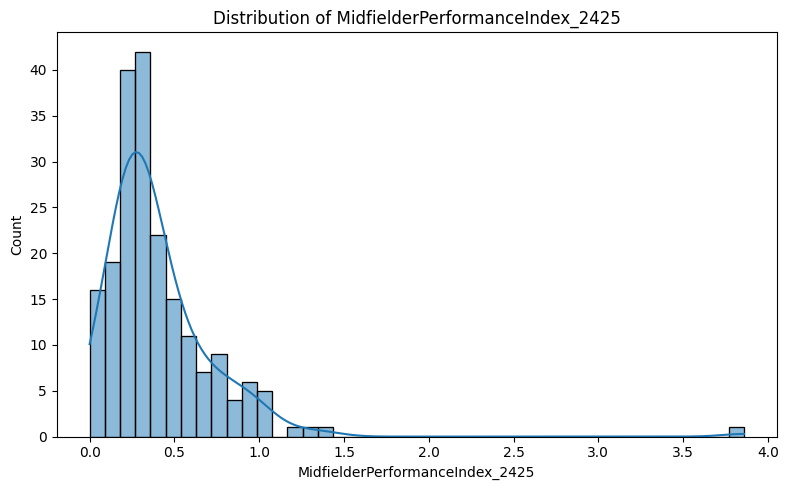

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_out["MidfielderPerformanceIndex_2425"], kde=True)
plt.title("Distribution of MidfielderPerformanceIndex_2425")
plt.xlabel("MidfielderPerformanceIndex_2425")
plt.tight_layout()
plt.savefig("/content/eda_1_striker_performance_distribution.png", dpi=300)
plt.show()


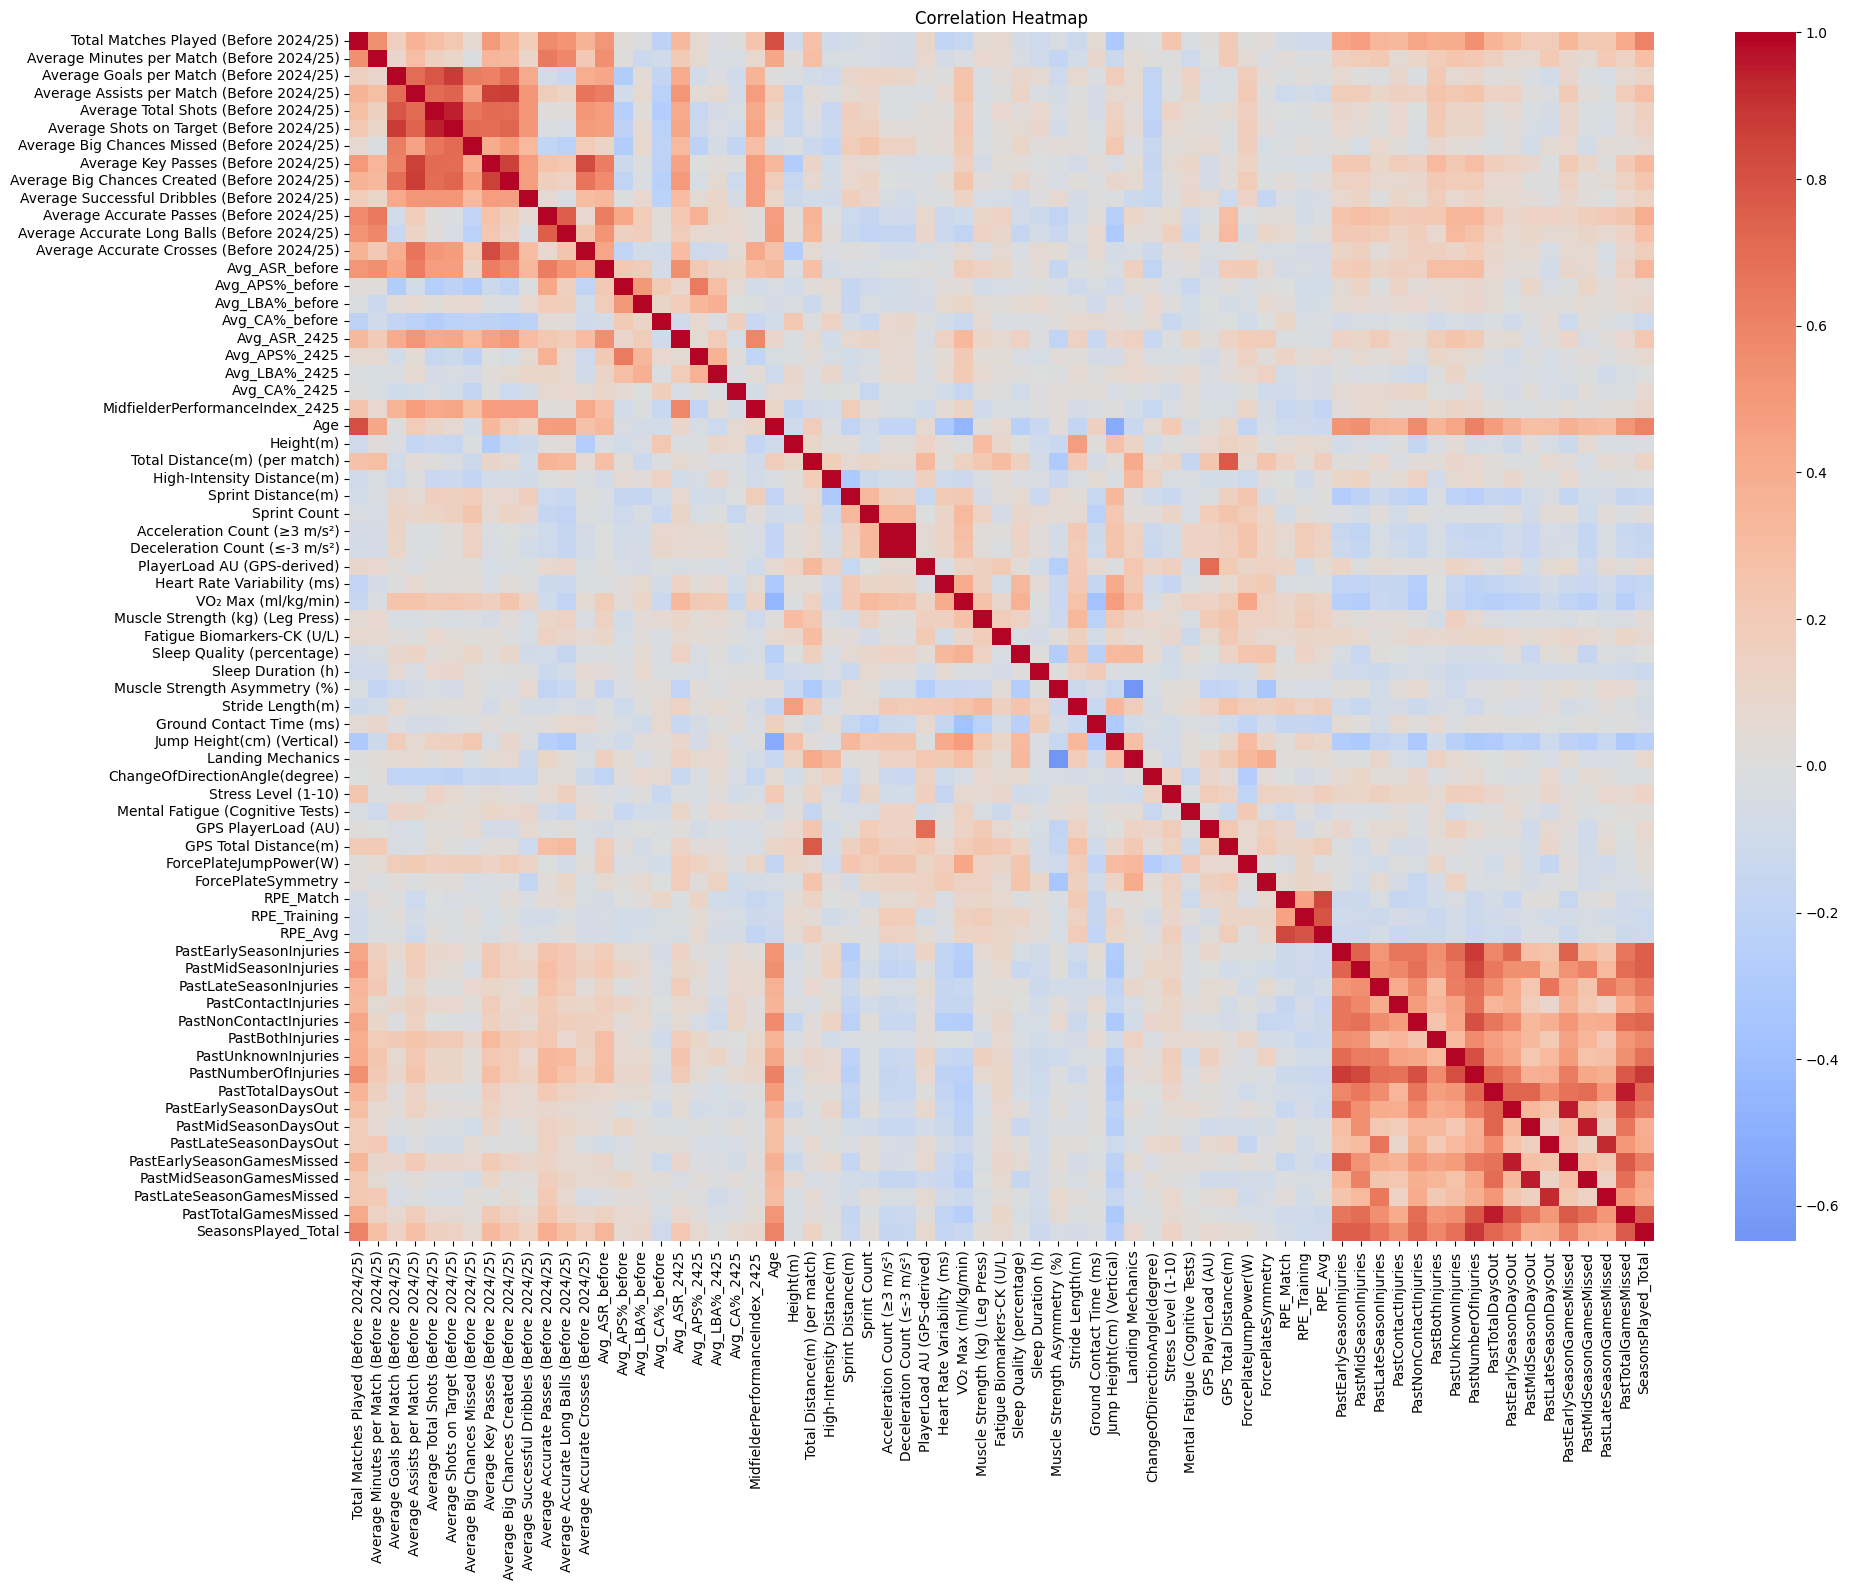

In [ ]:
plt.figure(figsize=(20,16))
sns.heatmap(df_out.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("/content/eda_2_correlation_heatmap.png", dpi=300)
plt.show()



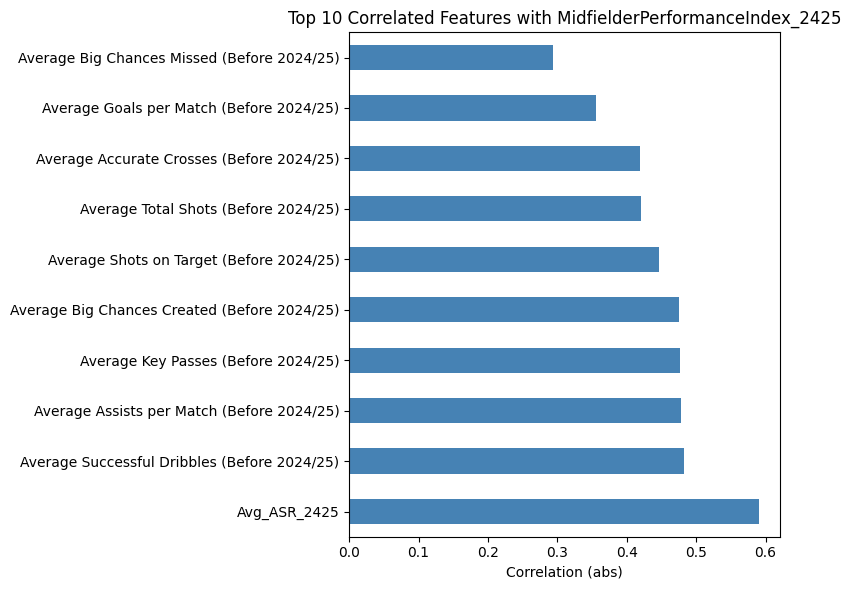

In [ ]:
corr_target = df_out.corr()["MidfielderPerformanceIndex_2425"].abs().sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_target[1:11].plot(kind='barh', color='steelblue')
plt.title("Top 10 Correlated Features with MidfielderPerformanceIndex_2425")
plt.xlabel("Correlation (abs)")
plt.tight_layout()
plt.savefig("/content/eda_3_top10_correlations.png", dpi=300)
plt.show()


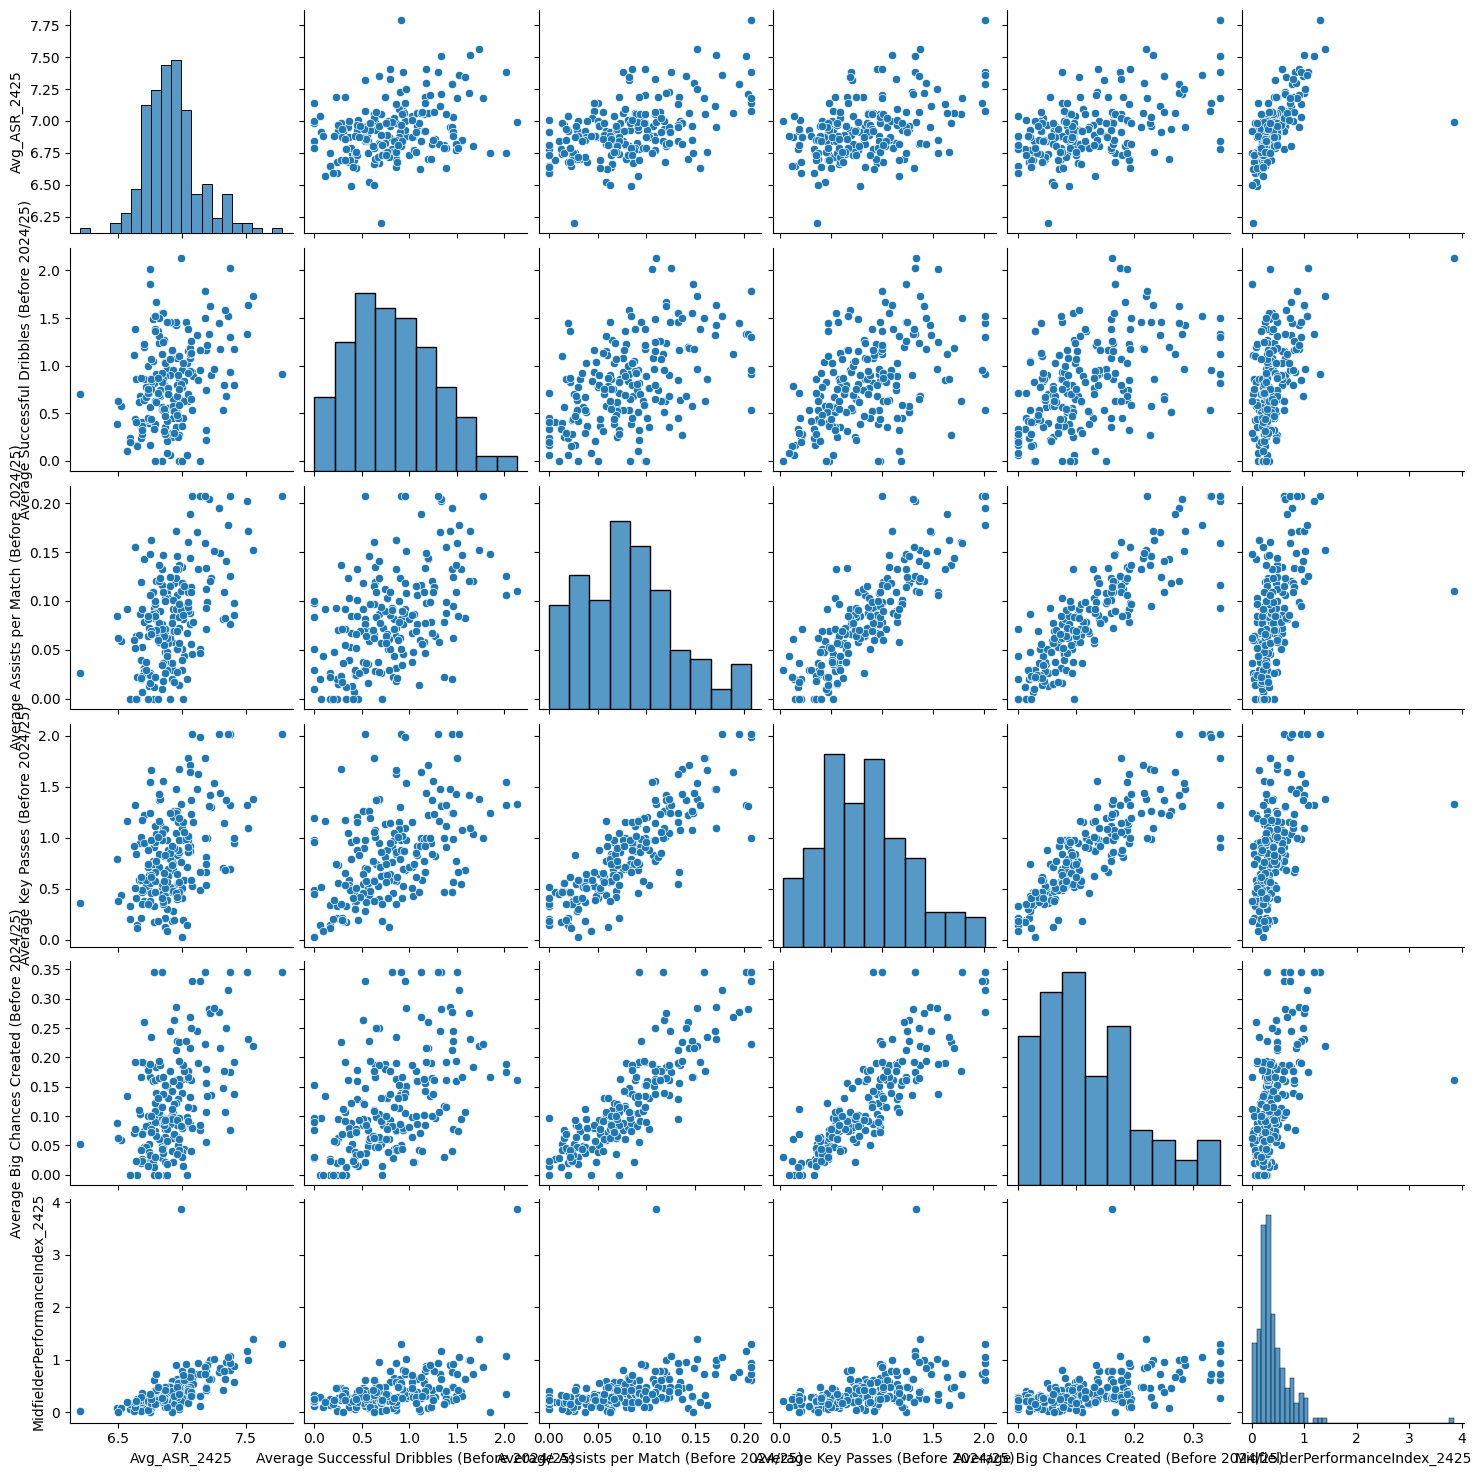

In [ ]:
top5 = corr_target.index[1:6]  # skip the target

sns.pairplot(df_out[top5.tolist() + ["MidfielderPerformanceIndex_2425"]])
plt.savefig("/content/eda_4_pairplot_top5.png", dpi=300)
plt.show()


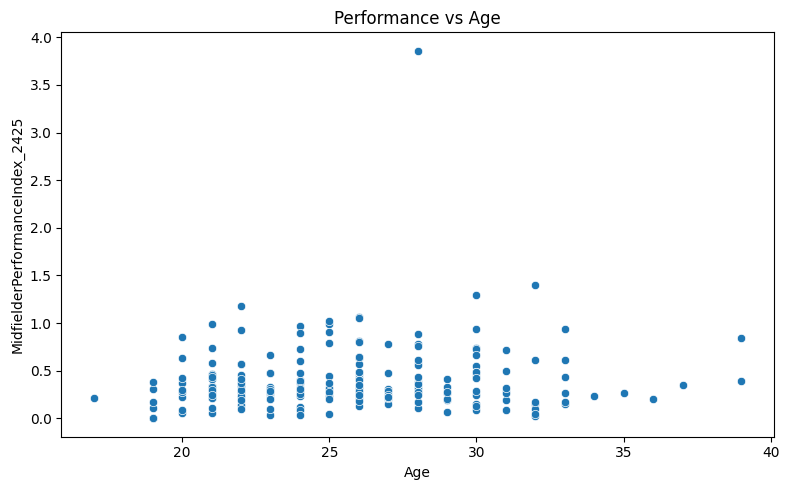

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="Age", y="MidfielderPerformanceIndex_2425")
plt.title("Performance vs Age")
plt.tight_layout()
plt.savefig("/content/eda_5_age_vs_performance.png", dpi=300)
plt.show()


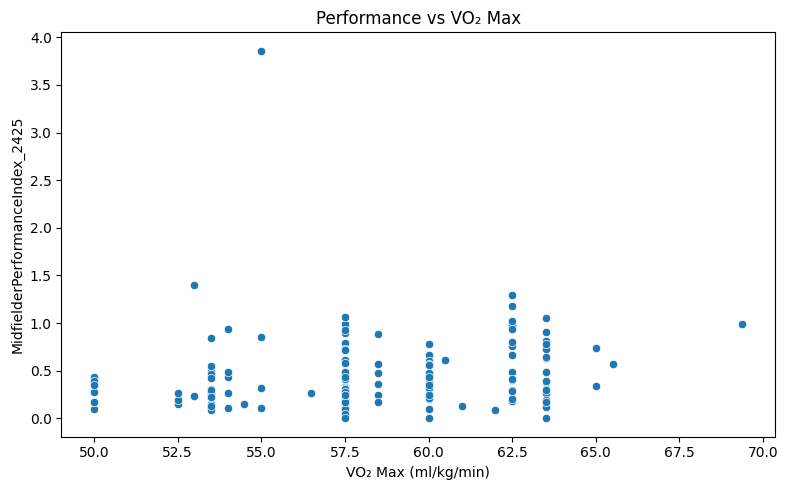

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="VO₂ Max (ml/kg/min)", y="MidfielderPerformanceIndex_2425")
plt.title("Performance vs VO₂ Max")
plt.tight_layout()
plt.savefig("/content/eda_6_vo2_vs_performance.png", dpi=300)
plt.show()


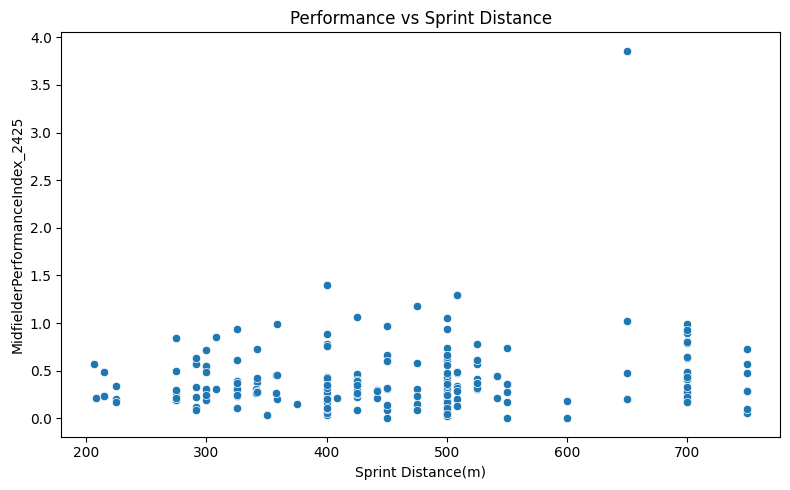

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="Sprint Distance(m)", y="MidfielderPerformanceIndex_2425")
plt.title("Performance vs Sprint Distance")
plt.tight_layout()
plt.savefig("/content/eda_7_sprint_distance_vs_performance.png", dpi=300)
plt.show()


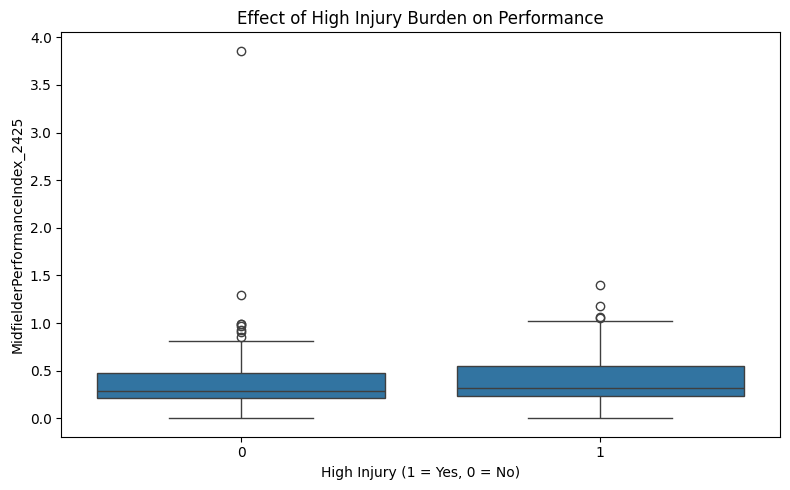

In [ ]:
df_out["HighInjury"] = (df_out["PastTotalDaysOut"] > df_out["PastTotalDaysOut"].median()).astype(int)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_out, x="HighInjury", y="MidfielderPerformanceIndex_2425")
plt.title("Effect of High Injury Burden on Performance")
plt.xlabel("High Injury (1 = Yes, 0 = No)")
plt.tight_layout()
plt.savefig("/content/eda_8_injury_vs_performance.png", dpi=300)
plt.show()


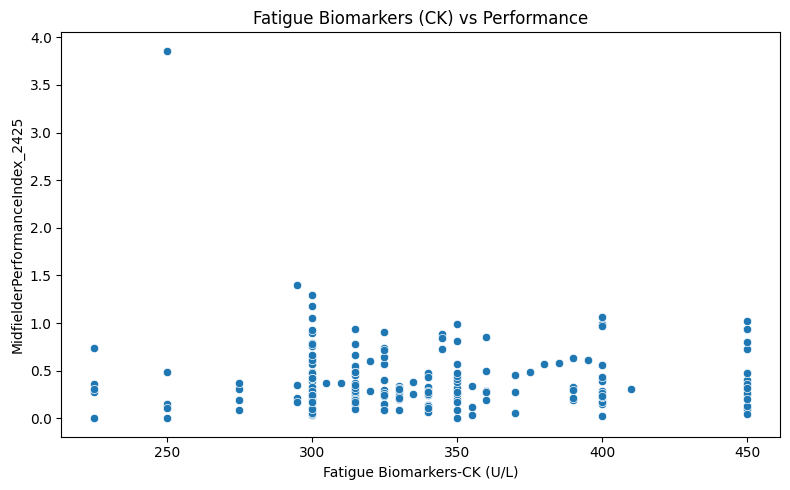

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="Fatigue Biomarkers-CK (U/L)", y="MidfielderPerformanceIndex_2425")
plt.title("Fatigue Biomarkers (CK) vs Performance")
plt.tight_layout()
plt.savefig("/content/eda_9_ck_vs_performance.png", dpi=300)
plt.show()


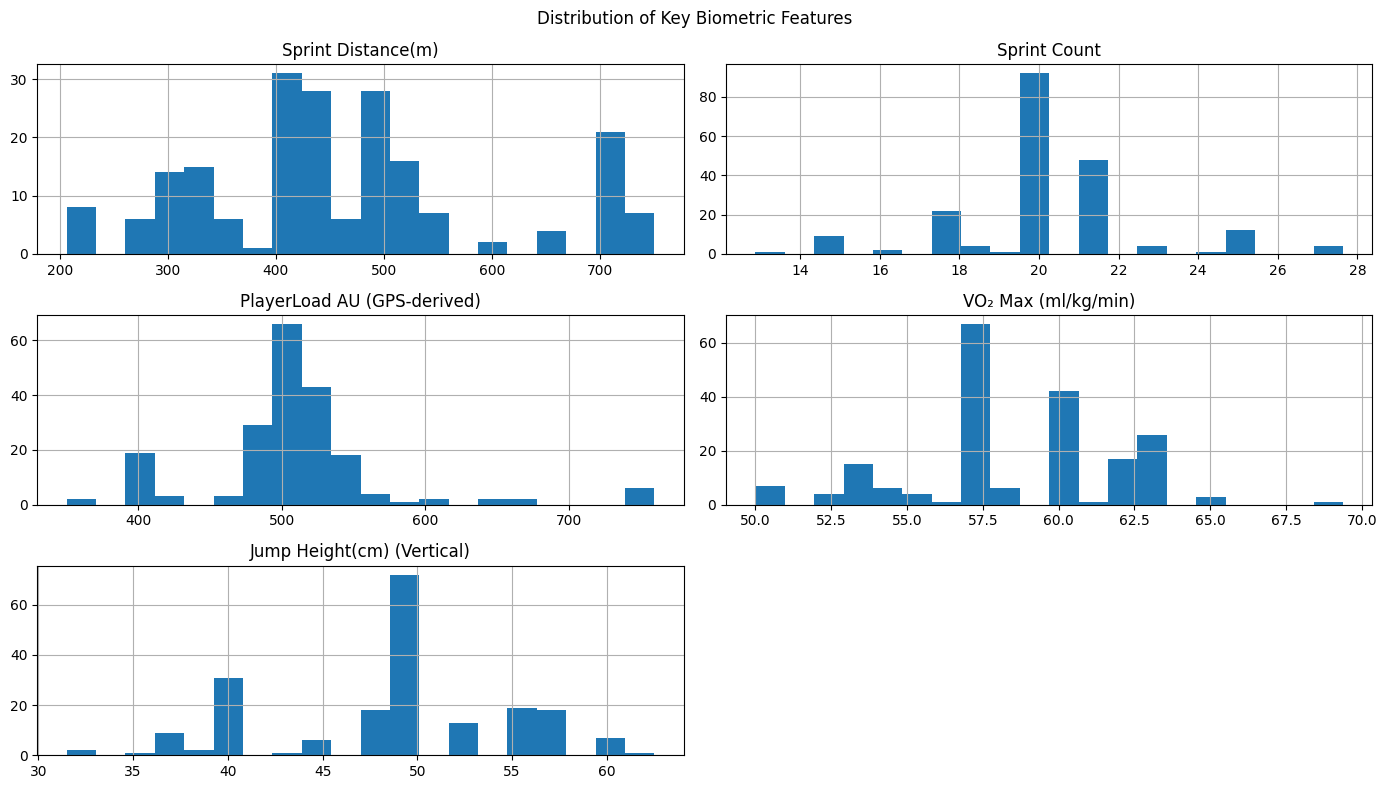

In [ ]:
key_bio = [
    "Sprint Distance(m)",
    "Sprint Count",
    "PlayerLoad AU (GPS-derived)",
    "VO₂ Max (ml/kg/min)",
    "Jump Height(cm) (Vertical)"
]

df_out[key_bio].hist(figsize=(14,8), bins=20)
plt.suptitle("Distribution of Key Biometric Features")
plt.tight_layout()
plt.savefig("/content/eda_10_key_biometric_distributions.png", dpi=300)
plt.show()


***Train test split***

In [ ]:
import pandas as pd
import json
import joblib  # if not already imported

# 1. Target
y = df_out["MidfielderPerformanceIndex_2425"]  # your target column

# 2. Features = ALL columns except target
X = df_out.drop(columns=["MidfielderPerformanceIndex_2425"])

# 3. Save full feature list (order matters for GUI)
full_features = list(X.columns)
with open("midfielder_all_features.json", "w", encoding="utf-8") as f:
    json.dump(full_features, f)

# 4. Save feature means (for filling missing features in GUI)
means = X.mean(numeric_only=True).to_dict()
with open("midfielder_feature_means.json", "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in means.items()}, f)

print("Saved midfielder_all_features.json and midfielder_feature_means.json")


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Saved midfielder_all_features.json and midfielder_feature_means.json


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"\n{name} Results:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


***model run***

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

evaluate(rf, X_test, y_test, "Random Forest Regressor")



Random Forest Regressor Results:
MAE  : 0.1001
RMSE : 0.1350
R²   : 0.6400


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

evaluate(xgb, X_test, y_test, "XGBoost Regressor")



XGBoost Regressor Results:
MAE  : 0.1005
RMSE : 0.1299
R²   : 0.6665


In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)
lgbm.fit(X_train, y_train)

evaluate(lgbm, X_test, y_test, "LightGBM Regressor")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1803
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 69
[LightGBM] [Info] Start training from score 0.427851
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

evaluate(lr, X_test_scaled, y_test, "Linear Regression")



Linear Regression Results:
MAE  : 0.2393
RMSE : 0.3209
R²   : -1.0341


In [ ]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    random_state=42
)
elastic.fit(X_train_scaled, y_train)

evaluate(elastic, X_test_scaled, y_test, "ElasticNet Regression")



ElasticNet Regression Results:
MAE  : 0.2230
RMSE : 0.2964
R²   : -0.7347


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=False,
    random_state=42
)
cat.fit(X_train, y_train)

evaluate(cat, X_test, y_test, "CatBoost Regressor")



CatBoost Regressor Results:
MAE  : 0.1101
RMSE : 0.1511
R²   : 0.5492


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []   # store each model's performance here

def evaluate_to_table(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })


# Tree-based models (no scaling)
evaluate_to_table(rf,   X_test, y_test, "Random Forest Regressor")
evaluate_to_table(xgb,  X_test, y_test, "XGBoost Regressor")
evaluate_to_table(lgbm, X_test, y_test, "LightGBM Regressor")
evaluate_to_table(cat,  X_test, y_test, "CatBoost Regressor")

# Linear models (scaled)
evaluate_to_table(lr,       X_test_scaled, y_test, "Linear Regression")
evaluate_to_table(elastic,  X_test_scaled, y_test, "ElasticNet Regression")



results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")

print(results_df)


                     Model       MAE      RMSE  R² Score
1        XGBoost Regressor  0.100531  0.129946  0.666480
0  Random Forest Regressor  0.100061  0.135007  0.639993
3       CatBoost Regressor  0.110142  0.151072  0.549219
2       LightGBM Regressor  0.191065  0.247843 -0.213252
5    ElasticNet Regression  0.222974  0.296358 -0.734730
4        Linear Regression  0.239346  0.320911 -1.034083


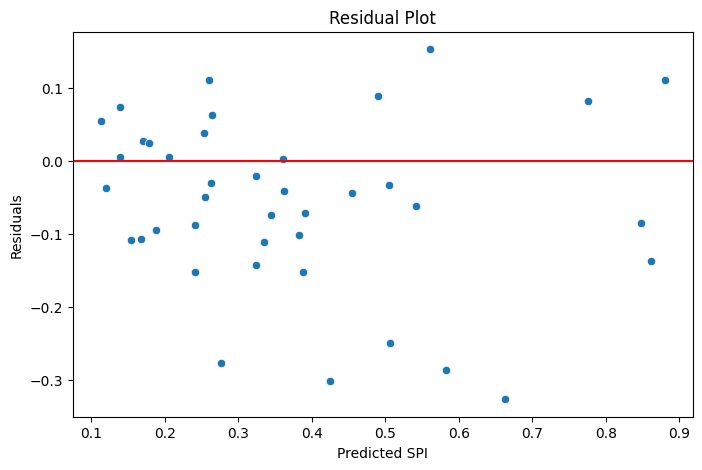

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

preds = xgb.predict(X_test)
residuals = y_test - preds

plt.figure(figsize=(8,5))
sns.scatterplot(x=preds, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted SPI")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
from xgboost import XGBRegressor

# Re-initialize and re-fit the XGBoost model
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

print("XGBoost model has been re-fitted.")

XGBoost model has been re-fitted.


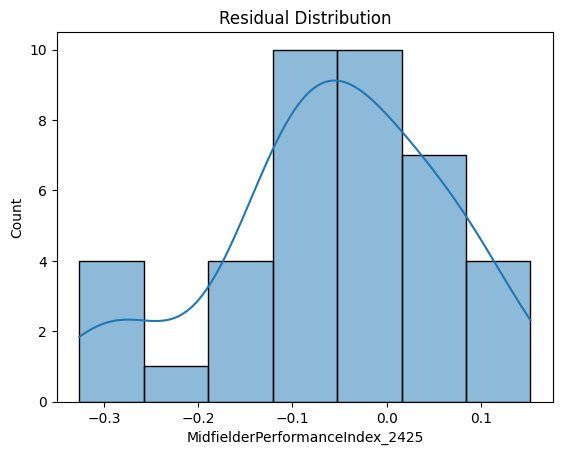

In [ ]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


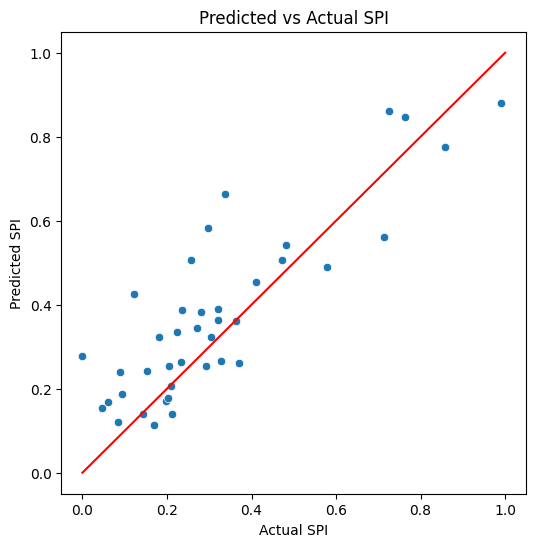

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=preds)
plt.plot([0,1],[0,1], color='red')
plt.xlabel("Actual SPI")
plt.ylabel("Predicted SPI")
plt.title("Predicted vs Actual SPI")
plt.show()


In [ ]:
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_imp.head(55))

Avg_ASR_2425                                    0.144257
Average Successful Dribbles (Before 2024/25)    0.133960
Acceleration Count (≥3 m/s²)                    0.097645
Average Key Passes (Before 2024/25)             0.083560
ChangeOfDirectionAngle(degree)                  0.065162
Average Total Shots (Before 2024/25)            0.049888
Stride Length(m)                                0.032945
Average Big Chances Created (Before 2024/25)    0.031508
Average Shots on Target (Before 2024/25)        0.022299
RPE_Match                                       0.017251
Sleep Quality (percentage)                      0.016919
Sleep Duration (h)                              0.015506
Total Matches Played (Before 2024/25)           0.014636
Average Accurate Crosses (Before 2024/25)       0.014391
Avg_APS%_2425                                   0.013164
Average Accurate Passes (Before 2024/25)        0.012853
Average Assists per Match (Before 2024/25)      0.012223
Average Big Chances Missed (Bef

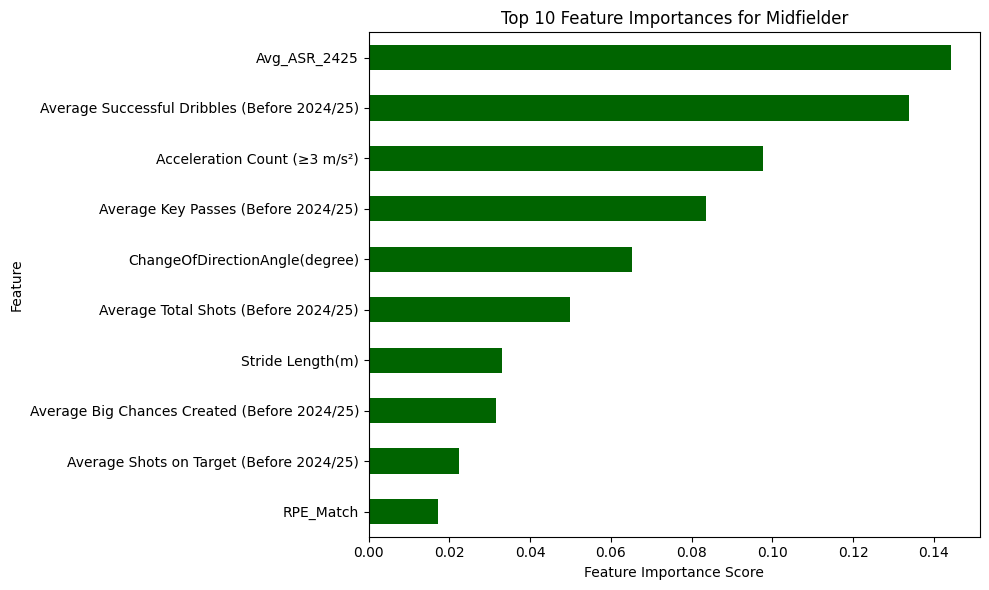

In [ ]:
plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='barh', color='darkgreen')
plt.title('Top 10 Feature Importances for Midfielder')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # To display the most important feature at the top
plt.tight_layout()
plt.savefig('/content/xgb_top10_features.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----- X, y -----
target_col = "MidfielderPerformanceIndex_2425"

X = df_out.drop(columns=[target_col])
y = df_out[target_col]

# ----- Train / test -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----- Evaluation helper -----
def evaluate_model(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    print(f"\n{name}")
    print("-"*40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 4, 6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["auto", "sqrt", 0.5]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
evaluate_model(rf_search.best_estimator_, X_test, y_test, "Random Forest (tuned)")


Best RF params: {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_depth': None}

Random Forest (tuned)
----------------------------------------
MAE  : 0.1260
RMSE : 0.1888
R²   : 0.2962


In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

lgbm_params = {
    "n_estimators": [200, 400, 600, 800],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=40,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

print("\nBest LGBM params:", lgbm_search.best_params_)
evaluate_model(lgbm_search.best_estimator_, X_test, y_test, "LightGBM (tuned)")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1803
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 69
[LightGBM] [Info] Start training from score 0.427851
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

cat_params = {
    "iterations": [300, 500, 800],
    "depth": [4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=cat_params,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

print("\nBest CatBoost params:", cat_search.best_params_)
evaluate_model(cat_search.best_estimator_, X_test, y_test, "CatBoost (tuned)")


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

results_compare = []

def eval_store(model, Xtest, ytest, name):
    preds = model.predict(Xtest)
    mae  = mean_absolute_error(ytest, preds)
    rmse = np.sqrt(mean_squared_error(ytest, preds))
    r2   = r2_score(ytest, preds)

    results_compare.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


# -----------------------------
# Assume X_train, X_test, y_train, y_test already exist
# If not, recreate them from df_out:
# X = df_out.drop(columns=["Striker Performance Index"])
# y = df_out["Striker Performance Index"]
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# -----------------------------

# ---- scaling for linear models ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---------- BASELINE MODELS (refit here) ----------

rf_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_base.fit(X_train, y_train)
eval_store(rf_base, X_test, y_test, "Random Forest (baseline)")

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_base.fit(X_train, y_train)
eval_store(xgb_base, X_test, y_test, "XGBoost (baseline)")

lgbm_base = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
lgbm_base.fit(X_train, y_train)
eval_store(lgbm_base, X_test, y_test, "LightGBM (baseline)")

cat_base = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=False,
    random_state=42
)
cat_base.fit(X_train, y_train)
eval_store(cat_base, X_test, y_test, "CatBoost (baseline)")

lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train)
eval_store(lr_base, X_test_scaled, y_test, "Linear Regression (baseline)")

elastic_base = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    random_state=42
)
elastic_base.fit(X_train_scaled, y_train)
eval_store(elastic_base, X_test_scaled, y_test, "ElasticNet (baseline)")


# ---------- TUNED MODELS (already fitted by RandomizedSearchCV) ----------

# Re-define and fit xgb_search here
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_params = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.4],
    "lambda": [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=40, # Number of parameter settings that are sampled
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

eval_store(rf_search.best_estimator_,   X_test, y_test, "Random Forest (tuned)")
eval_store(xgb_search.best_estimator_,  X_test, y_test, "XGBoost (tuned)")
eval_store(lgbm_search.best_estimator_, X_test, y_test, "LightGBM (tuned)")
eval_store(cat_search.best_estimator_,  X_test, y_test, "CatBoost (tuned)")


# ---------- RESULT TABLE ----------

df_compare = pd.DataFrame(results_compare)
df_compare = df_compare.sort_values(by="R²", ascending=False)
print(df_compare)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_params = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.4],
    "lambda": [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=40, # Number of parameter settings that are sampled
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGB params:", xgb_search.best_params_)
evaluate_model(xgb_search.best_estimator_, X_test, y_test, "XGBoost (tuned)")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import StandardScaler

results_compare = []

def eval_store(model, Xtest, ytest, name):
    preds = model.predict(Xtest)
    mae  = mean_absolute_error(ytest, preds)
    rmse = np.sqrt(mean_squared_error(ytest, preds))
    r2   = r2_score(ytest, preds)

    results_compare.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


# -----------------------------
# Assume X_train, X_test, y_train, y_test already exist
# If not, recreate them from df_out:
# X = df_out.drop(columns=["Striker Performance Index"])
# y = df_out["Striker Performance Index"]
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# -----------------------------

# ---- scaling for linear models ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---------- BASELINE MODELS (refit here) ----------

rf_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_base.fit(X_train, y_train)
eval_store(rf_base, X_test, y_test, "Random Forest (baseline)")

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_base.fit(X_train, y_train)
eval_store(xgb_base, X_test, y_test, "XGBoost (baseline)")

lgbm_base = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
lgbm_base.fit(X_train, y_train)
eval_store(lgbm_base, X_test, y_test, "LightGBM (baseline)")

cat_base = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=False,
    random_state=42
)
cat_base.fit(X_train, y_train)
eval_store(cat_base, X_test, y_test, "CatBoost (baseline)")

lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train)
eval_store(lr_base, X_test_scaled, y_test, "Linear Regression (baseline)")

elastic_base = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    random_state=42
)
elastic_base.fit(X_train_scaled, y_train)
eval_store(elastic_base, X_test_scaled, y_test, "ElasticNet (baseline)")


# ---------- TUNED MODELS (already fitted by RandomizedSearchCV) ----------

eval_store(rf_search.best_estimator_,   X_test, y_test, "Random Forest (tuned)")
eval_store(xgb_search.best_estimator_,  X_test, y_test, "XGBoost (tuned)")
eval_store(lgbm_search.best_estimator_, X_test, y_test, "LightGBM (tuned)")
eval_store(cat_search.best_estimator_,  X_test, y_test, "CatBoost (tuned)")


# ---------- RESULT TABLE ----------

df_compare = pd.DataFrame(results_compare)
df_compare = df_compare.sort_values(by="R²", ascending=False)
print(df_compare)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_params = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.4],
    "lambda": [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=40, # Number of parameter settings that are sampled
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGB params:", xgb_search.best_params_)
evaluate_model(xgb_search.best_estimator_, X_test, y_test, "XGBoost (tuned)")


In [ ]:
import shap
import matplotlib.pyplot as plt

# rf_final should be your final RF model (e.g. rf_final = rf_base)
rf_final = rf_search.best_estimator_ # Assign the best tuned Random Forest estimator
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_train)

# -------- SHAP SUMMARY DOT PLOT --------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.savefig("shap_summary_dot.png", dpi=300, bbox_inches="tight")
plt.close()

# -------- SHAP SUMMARY BAR PLOT --------
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved:")
print(" - shap_summary_dot.png")
print(" - shap_summary_bar.png")

In [ ]:
from IPython.display import Image, display

display(Image(filename="shap_summary_dot.png"))
display(Image(filename="shap_summary_bar.png"))

In [ ]:
import joblib
import json

best_mid_model = xgb_search.best_estimator_ # Use the best tuned XGBoost model
joblib.dump(best_mid_model, "midfielder_model.pkl")

feature_names_mid = list(X.columns) # Use the global X DataFrame
with open("midfielder_features.json", "w") as f:
    json.dump(feature_names_mid, f)


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R²", data=df_compare, palette="viridis")
plt.title("Model Performance Comparison (R² Score)", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/model_r2_comparison.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="MAE", data=df_compare.sort_values(by="MAE"), palette="viridis")
plt.title("Model Performance Comparison (MAE)", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/model_mae_comparison.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="RMSE", data=df_compare.sort_values(by="RMSE"), palette="viridis")
plt.title("Model Performance Comparison (RMSE)", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/model_rmse_comparison.png", dpi=300)
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
     An object of that type which is cloned for each validation.

    title : string
        Title for the plot.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        optional Target vector relative to X.

    axes : array-like of 1x2 dimensions, optional
        Vector of axes for the plot.

    ylim : tuple, shape (ymin, ymax), optional
        Defines limits for the y-axis.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation, (default)
          - integer, to specify the number of folds.
          - An object to be used as a cross-validation generator.
          - An iterable yielding train/test splits.

        For integer/None inputs, if ``y`` is binary or multi-label, ``StratifiedKFold`` is used.
        If the estimator is not a classifier or ``y`` is neither binary nor multi-label,
        ``KFold`` is used.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel. `None` means 1 unless in a `joblib.parallel_backend` context.
        `-1` means using all processors.

    train_sizes : array-like, shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to generate the
        learning curve.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes.legend(loc="best")

    return axes


fig, axes = plt.subplots(1, 1, figsize=(10, 5))

title = "Learning Curves (XGBoost Regressor)"
plot_learning_curve(xgb_search.best_estimator_, title, X_train, y_train, axes=axes, cv=5, n_jobs=-1, ylim=(0.0, 1.1))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Get predictions from the best model (rf_base)
preds_test = rf_base.predict(X_test)

# 2. Calculate residuals
residuals = y_test - preds_test

# 3. Retrieve 'Position' for the test set players from the 'merged' DataFrame
# The indices of X_test (and y_test) correspond to the original merged DataFrame.
positions_for_test = merged.loc[X_test.index, 'Position']

# 4. Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Position': positions_for_test,
    'Residuals': residuals
})

# Filter for 'Midfielder' position only
Midfielder_plot_df = plot_df[plot_df['Position'] == 'Midfielder']

# 5. Generate the boxplot for Midfielders
plt.figure(figsize=(8, 6)) # Adjusted figure size for single position
sns.boxplot(data=Midfielder_plot_df, x='Position', y='Residuals', palette='viridis')
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Error')
plt.title('Prediction Error (Residuals) Distribution for Midfielders')
plt.xlabel('Player Position')
plt.ylabel('Residuals (Actual SPI - Predicted SPI)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/prediction_error_by_Midfielder_position_boxplot.png', dpi=300)
plt.show()

In [ ]:
import numpy as np

# 1. Calculate the 75th percentile of the 'MidfielderPerformanceIndex_2425'
threshold = df_out['MidfielderPerformanceIndex_2425'].quantile(0.75)
print(f"75th percentile (threshold) for MidfielderPerformanceIndex_2425: {threshold:.4f}\n")

# 2. Create the new binary target variable 'Performance_Class'
df_out['Performance_Class'] = (df_out['MidfielderPerformanceIndex_2425'] >= threshold).astype(int)

# 3. Display the first few rows of the df_out DataFrame
df_out.head()

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier  # Import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for classification
X_class = df_out.drop(columns=['MidfielderPerformanceIndex_2425', 'Performance_Class'])
y_class = df_out['Performance_Class']

# 2. Split data into training and testing sets (without scaling)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Shape of X_train_class: {X_train_class.shape}")
print(f"Shape of X_test_class: {X_test_class.shape}")
print(f"Value counts for y_train_class:\n{y_train_class.value_counts()}")
print(f"Value counts for y_test_class:\n{y_test_class.value_counts()}")

# 3. Train an XGBoost Classifier
xgb_classifier = XGBClassifier(n_estimators=300, random_state=42, use_label_encoder=False, eval_metric='logloss') # Using 'logloss' as eval_metric
xgb_classifier.fit(X_train_class, y_train_class)

# 4. Predict probabilities on the test set
y_pred_proba = xgb_classifier.predict_proba(X_test_class)[:, 1]

# 5. Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test_class, y_pred_proba)
auc_score = roc_auc_score(y_test_class, y_pred_proba)

# 6. Plot the ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', label='Random Classifier', color='gray')
sns.lineplot(x=fpr, y=tpr, label=f'XGBoost Classifier (AUC = {auc_score:.2f})', color='darkblue') # Changed label and color
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/roc_curve_high_performer_classification_xgb.png', dpi=300) # Changed filename
plt.show()

# 7. Summarize classification results
print(f"\nAUC Score for High Performer Classification (XGBoost): {auc_score:.4f}") # Changed print statement
print("\nInterpretation: The ROC curve visually represents the classifier's performance across all possible classification thresholds. The AUC score quantifies the overall performance, indicating the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance. A score of 0.5 suggests no discrimination (like a random classifier), while 1.0 indicates perfect separation. This analysis is supplementary to the regression task, aiming to understand the discriminative power of the features for extreme performance categories.")

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# Compute Precision-Recall curve and Average Precision (AP) score
precision, recall, _ = precision_recall_curve(y_test_class, y_pred_proba)
ap_score = average_precision_score(y_test_class, y_pred_proba)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=recall, y=precision, label=f'XGBoost Classifier (AP = {ap_score:.2f})', color='darkblue') # Changed label and color
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for High Performer Classification (XGBoost)') # Changed title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/precision_recall_curve_high_performer_classification_xgb.png', dpi=300) # Changed filename
plt.show()

print(f"\nAverage Precision (AP) Score for High Performer Classification (XGBoost): {ap_score:.4f}") # Changed print statement
print("\nInterpretation: The Precision-Recall curve illustrates the trade-off between precision and recall for different probability thresholds. High average precision indicates that the model has both high precision and high recall, which is desirable. This curve is particularly informative for imbalanced datasets where the positive class is rare, as it focuses on the performance of the positive class.")

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_learning_curve_rmse(estimator, title, X, y, axes=None, ylim=None, cv=None,
                                n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a plot of the training and validation RMSE learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
    title : string
        Title for the plot.
    X : array-like, shape (n_samples, n_features)
        Training vector.
    y : array-like, shape (n_samples)
        Target vector relative to X.
    axes : matplotlib axes, optional
        Axes to plot on. If None, a new figure and axes are created.
    ylim : tuple, shape (ymin, ymax), optional
        Defines limits for the y-axis.
    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
    train_sizes : array-like, shape (n_ticks,)
        Relative or absolute numbers of training examples.

    Returns
    -------
    matplotlib.axes.Axes
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("RMSE")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True, scoring='neg_mean_squared_error')

    # Convert negative MSE to RMSE
    train_rmse = np.sqrt(-train_scores)
    test_rmse = np.sqrt(-test_scores)

    train_rmse_mean = np.mean(train_rmse, axis=1)
    train_rmse_std = np.std(train_rmse, axis=1)
    test_rmse_mean = np.mean(test_rmse, axis=1)
    test_rmse_std = np.std(test_rmse, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_rmse_mean - train_rmse_std,
                         train_rmse_mean + train_rmse_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_rmse_mean - test_rmse_std,
                         test_rmse_mean + test_rmse_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_rmse_mean, 'o-', color="r",
                 label="Training RMSE")
    axes.plot(train_sizes, test_rmse_mean, 'o-', color="g",
                 label="Cross-validation RMSE")
    axes.legend(loc="best")

    return axes

# Assuming xgb_search.best_estimator_ is the best model after tuning
# And X_train, y_train are available from previous steps

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

title = "Learning Curves (XGBoost Regressor - RMSE)"
plot_learning_curve_rmse(xgb_search.best_estimator_, title, X_train, y_train, axes=axes, cv=5, n_jobs=-1, ylim=(0.0, None))
plt.show()